# Analisis Exploratorio de Datos (EDA) - Sistema Predictivo de Comercializacion

> **Objetivo:** Explorar, limpiar y caracterizar el dataset *Store Sales - Corporacion Favorita* para validar su aptitud para modelos de regresion, clasificacion y clustering.
>
> **Metodologia:** Pipeline reproducible implementado en el paquete `spc`. Se analizan 7 archivos CSV con historial de ventas (2013-2017), tiendas, productos, promociones, transacciones, precio del petroleo y calendario de feriados.

---

## 1. Configuracion del Entorno y Ejecucion del Pipeline

Cargamos las librerias necesarias y ejecutamos el pipeline completo que realiza: carga de datos, perfilado, calidad, analisis univariado/bivariado/temporal, integracion de fuentes, correlaciones, clasificacion y clustering.

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import json as _json
import warnings
from IPython.display import display, Image, Markdown

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

# Ubicar la raiz del proyecto
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
os.chdir(root)

import spc

# Ejecutar pipeline completo
resultados = spc.run_pipeline()

processed = Path('data/processed')
figures = Path('figures')

print("Pipeline ejecutado exitosamente.")
print(f"Figuras generadas: {resultados['n_figuras']}")
print(f"Reporte en: {resultados['reporte']}")

02:01:45 | INFO    | spc.pipeline | Iniciando pipeline EDA (base=d:\UPAO\IX\Taller Integrador I\sistema_prediccion_comercializacion)
02:01:45 | INFO    | spc.io.loaders | Archivos verificados: 7/7 presentes
02:01:49 | INFO    | spc.io.loaders | Carga completa: train=3000888 filas, integrando 7 fuentes
02:02:21 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
02:02:21 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
02:02:29 | INFO    | matplotlib.category | Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting

Pipeline ejecutado exitosamente.
Figuras generadas: 19
Reporte en: d:\UPAO\IX\Taller Integrador I\sistema_prediccion_comercializacion\reporte_eda.md


---
## 2. Perfilado General de Archivos

Se verifican los 7 archivos del dataset. La tabla muestra dimensiones, peso en memoria, rango temporal y estadisticas clave de cada archivo.

In [2]:
perfil = pd.read_csv(processed / 'resumen_perfil_archivos.csv')
display(perfil)

,archivo,filas,columnas,memoria_mb,rango_fechas,tiendas_unicas,familias_unicas,duplicados,pct_nulos_total,columnas_y_tipos
0,train,3000888,6,60.1013,2013-01-01 a 2017-08-15,54.0000,33.0000,0,0.0000,"id: int32, date: datetime64[us], store_nbr: in..."
1,test,28512,5,0.4643,2017-08-16 a 2017-08-31,54.0000,33.0000,0,0.0000,"id: int32, date: datetime64[us], store_nbr: in..."
2,stores,54,5,0.0040,NaN,54.0000,NaN,0,0.0000,"store_nbr: int16, city: category, state: categ..."
3,transactions,83488,3,1.1148,2013-01-01 a 2017-08-15,54.0000,NaN,0,0.0000,"date: datetime64[us], store_nbr: int16, transa..."
4,oil,1218,2,0.0141,2013-01-01 a 2017-08-31,NaN,NaN,0,1.7652,"date: datetime64[us], dcoilwtico: float32"
5,holidays_events,350,6,0.0133,2012-03-02 a 2017-12-26,NaN,NaN,0,0.0000,"date: datetime64[us], type: category, locale: ..."
6,sample_submission,28512,2,0.2177,NaN,NaN,NaN,0,0.0000,"id: int32, sales: float32"


### Interpretacion
- **train.csv** es el archivo principal con ~3 millones de filas y rango 2013-2017. Contiene la variable objetivo `sales`.
- **test.csv** cubre solo 16 dias (16-31 agosto 2017), lo que confirma separacion temporal limpia con train.
- **stores.csv** es la tabla maestra de 54 tiendas con atributos geograficos y de tipo.
- **transactions.csv** registra flujo diario de clientes por tienda.
- **oil.csv** contiene la serie macro del precio del petroleo WTI (con huecos naturales en fines de semana).
- **holidays_events.csv** cataloga 350 feriados/eventos con alcance nacional, regional y local.

> **Conclusion:** Todos los archivos esperados estan presentes y con tamanos coherentes.

---
## 3. Calidad de Datos

Se evaluan nulos, duplicados, valores anomalos y consistencia referencial.

In [3]:
print("=== Columnas con valores nulos ===")
display(pd.read_csv(processed / 'resumen_nulos_columnas.csv'))
print()
print("=== Chequeos de calidad ===")
calidad = _json.loads((processed / 'resumen_calidad.json').read_text())
for k, v in calidad.items():
    print(f"  {k}: {v}")

=== Columnas con valores nulos ===


,archivo,columna,nulos,pct_nulos
0,train,id,0,0.0000
1,train,date,0,0.0000
2,train,store_nbr,0,0.0000
3,train,family,0,0.0000
4,train,sales,0,0.0000
5,train,onpromotion,0,0.0000
6,test,id,0,0.0000
7,test,date,0,0.0000
8,test,store_nbr,0,0.0000
9,test,family,0,0.0000



=== Chequeos de calidad ===
  train_store_not_in_stores: []
  test_store_not_in_stores: []
  transactions_store_not_in_stores: []
  sales_negative: 0
  sales_zero: 939130
  onpromotion_negative_train: 0
  onpromotion_negative_test: 0
  transactions_negative: 0
  oil_non_positive: 0
  oil_null_original: 43
  holidays_transferred_true: 12
  test_overlap_train_dates: 0
  train_date_min: 2013-01-01
  train_date_max: 2017-08-15
  train_missing_dates_in_range: 4
  test_date_min: 2017-08-16
  test_date_max: 2017-08-31
  test_missing_dates_in_range: 0
  transactions_date_min: 2013-01-01
  transactions_date_max: 2017-08-15
  transactions_missing_dates_in_range: 6
  oil_date_min: 2013-01-01
  oil_date_max: 2017-08-31
  oil_missing_dates_in_range: 486
  holidays_events_date_min: 2012-03-02
  holidays_events_date_max: 2017-12-26
  holidays_events_missing_dates_in_range: 1814


### Interpretacion
- **Sin duplicados** en ninguno de los 7 archivos.
- **Nulos:** solo `oil.dcoilwtico` tiene 43 nulos originales (3.5%), correspondientes a dias de mercado cerrado. Adicionalmente hay 486 fechas faltantes dentro del rango (fines de semana y feriados bursatiles).
- **Consistencia referencial:** todas las tiendas de train/test/transactions existen en stores (0 huerfanas).
- **Solapamiento temporal:** 0 fechas compartidas entre train y test (particion limpia).
- **Ventas negativas:** 0 (dato limpio).
- **Ventas en cero:** 939,130 filas (31.3%) — fenomeno real de familias sin demanda ciertos dias.
- **Feriados transferidos:** 12 eventos con `transferred=True` que requieren tratamiento especial.

> **Conclusion:** La calidad es alta. Los unicos nulos son operativos (petroleo) y se manejan con forward-fill.

---
## 4. Variable Objetivo: `sales`

Analizamos la distribucion de la variable a predecir para entender su forma, escala y anomalias.

In [4]:
print("=== Estadisticos descriptivos de sales ===")
display(pd.read_csv(processed / 'sales_descriptivos.csv'))

=== Estadisticos descriptivos de sales ===


,Unnamed: 0,sales
0,count,"3,000,888.0000"
1,mean,357.7757
2,std,"1,101.9977"
3,min,0.0000
4,1%,0.0000
5,5%,0.0000
6,25%,0.0000
7,50%,11.0000
8,75%,195.8473
9,95%,"1,965.0000"


=== Distribucion original de sales ===


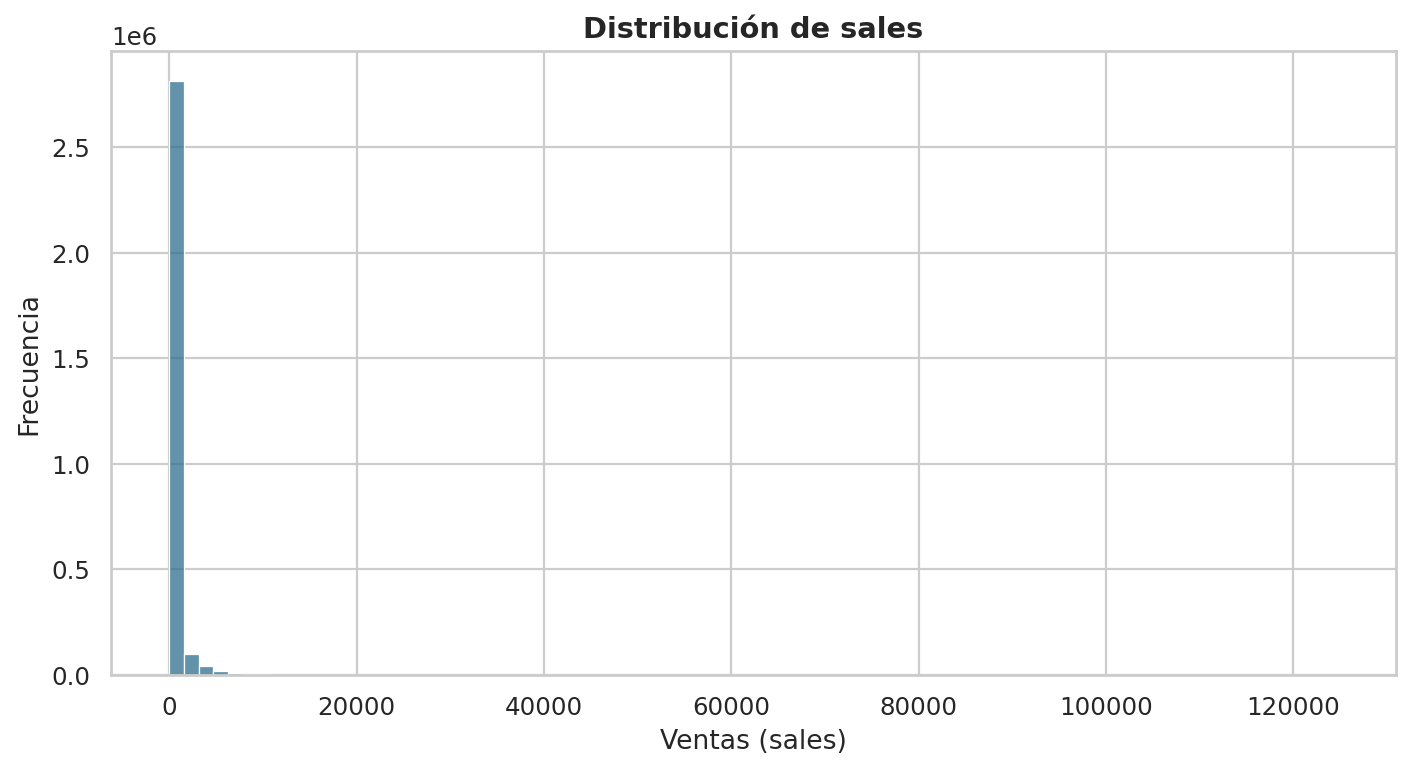

In [5]:
print("=== Distribucion original de sales ===")
display(Image(filename=str(figures / '01_distribucion_sales.png'), width=700))

### Interpretacion - Distribucion Original
- La distribucion es **extremadamente asimetrica** (asimetria = 7.36) con una cola derecha muy larga.
- El **31.3% de las observaciones son ceros** (familias sin ventas ese dia).
- La mediana (11.0) es drasticamente menor que la media (357.8), confirmando el sesgo positivo.
- Curtosis = 154.6 indica una concentracion extrema con outliers lejanos (max = 124,717).
- **Coeficiente de variacion = 3.08** (desviacion estandar es 3x la media): alta heterogeneidad.

> **Implicacion para modelado:** No se puede usar la variable cruda como objetivo de regresion lineal.

=== Distribucion log-transformada ===


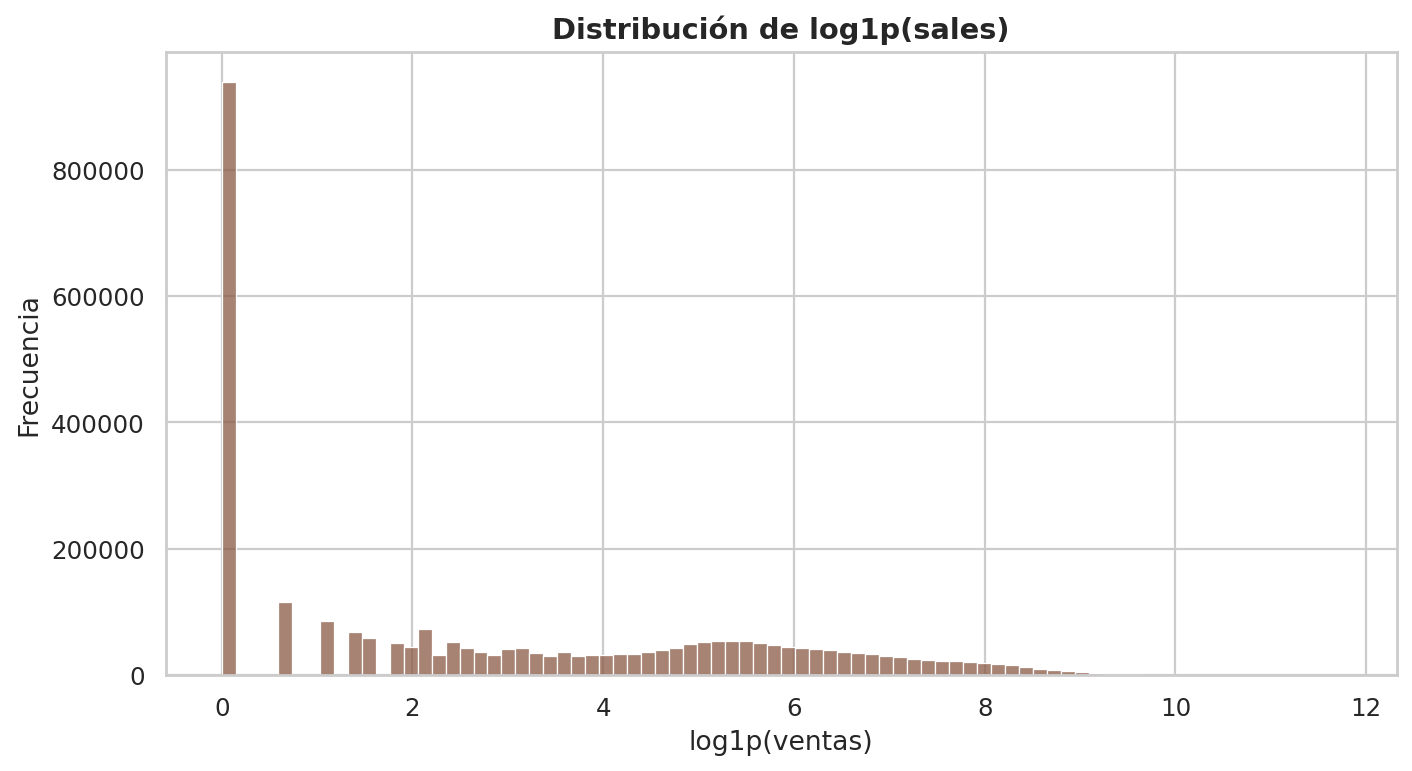

In [6]:
print("=== Distribucion log-transformada ===")
display(Image(filename=str(figures / '02_distribucion_log_sales.png'), width=700))

### Interpretacion - Distribucion Log-Transformada
- Tras aplicar `log1p(sales)`, la asimetria se reduce de 7.36 a **0.41** (casi simetrica).
- La curtosis pasa de 154.6 a **-1.15** (ligeramente platicurtica, sin colas extremas).
- La forma bimodal se debe a la masa de ceros (log1p(0) = 0) versus las ventas positivas.

> **Decision:** Usar `log1p(sales)` como objetivo para modelos de regresion. Considerar modelos zero-inflated o tratar ceros como clase separada.

In [7]:
print("=== Top 10 familias por ventas totales ===")
display(pd.read_csv(processed / 'sales_por_familia.csv').head(10))

=== Top 10 familias por ventas totales ===


,family,filas,ventas_total,media,mediana,maximo,desv,coef_variacion,pct_ceros
0,GROCERY I,90936,"343,462,720.0000","3,776.9720","3,185.0000","124,717.0000","2,874.2087",0.7610,8.0628
1,BEVERAGES,90936,"216,954,480.0000","2,385.7930","1,784.0000","25,413.0000","2,307.8823",0.9673,8.0617
2,PRODUCE,90936,"122,704,690.0000","1,349.3522",398.2905,"17,850.6150","2,186.4814",1.6204,28.3551
3,CLEANING,90936,"97,521,290.0000","1,072.4167",938.0000,"11,377.0000",734.6815,0.6851,8.0617
4,DAIRY,90936,"64,487,708.0000",709.1549,520.0000,"5,636.0000",671.9497,0.9475,8.0617
5,BREAD/BAKERY,90936,"42,133,944.0000",463.3362,401.0000,"4,551.2980",368.2464,0.7948,8.0606
6,POULTRY,90936,"31,876,004.0000",350.5323,205.7430,"12,143.2010",400.5116,1.1426,8.0760
7,MEATS,90936,"31,086,468.0000",341.8500,224.9365,"89,576.3600",455.9085,1.3337,8.0617
8,PERSONAL CARE,90936,"24,592,052.0000",270.4325,222.0000,"7,504.0000",226.5120,0.8376,8.0650
9,DELI,90936,"24,110,322.0000",265.1351,218.9715,"2,118.3250",210.4171,0.7936,8.0617


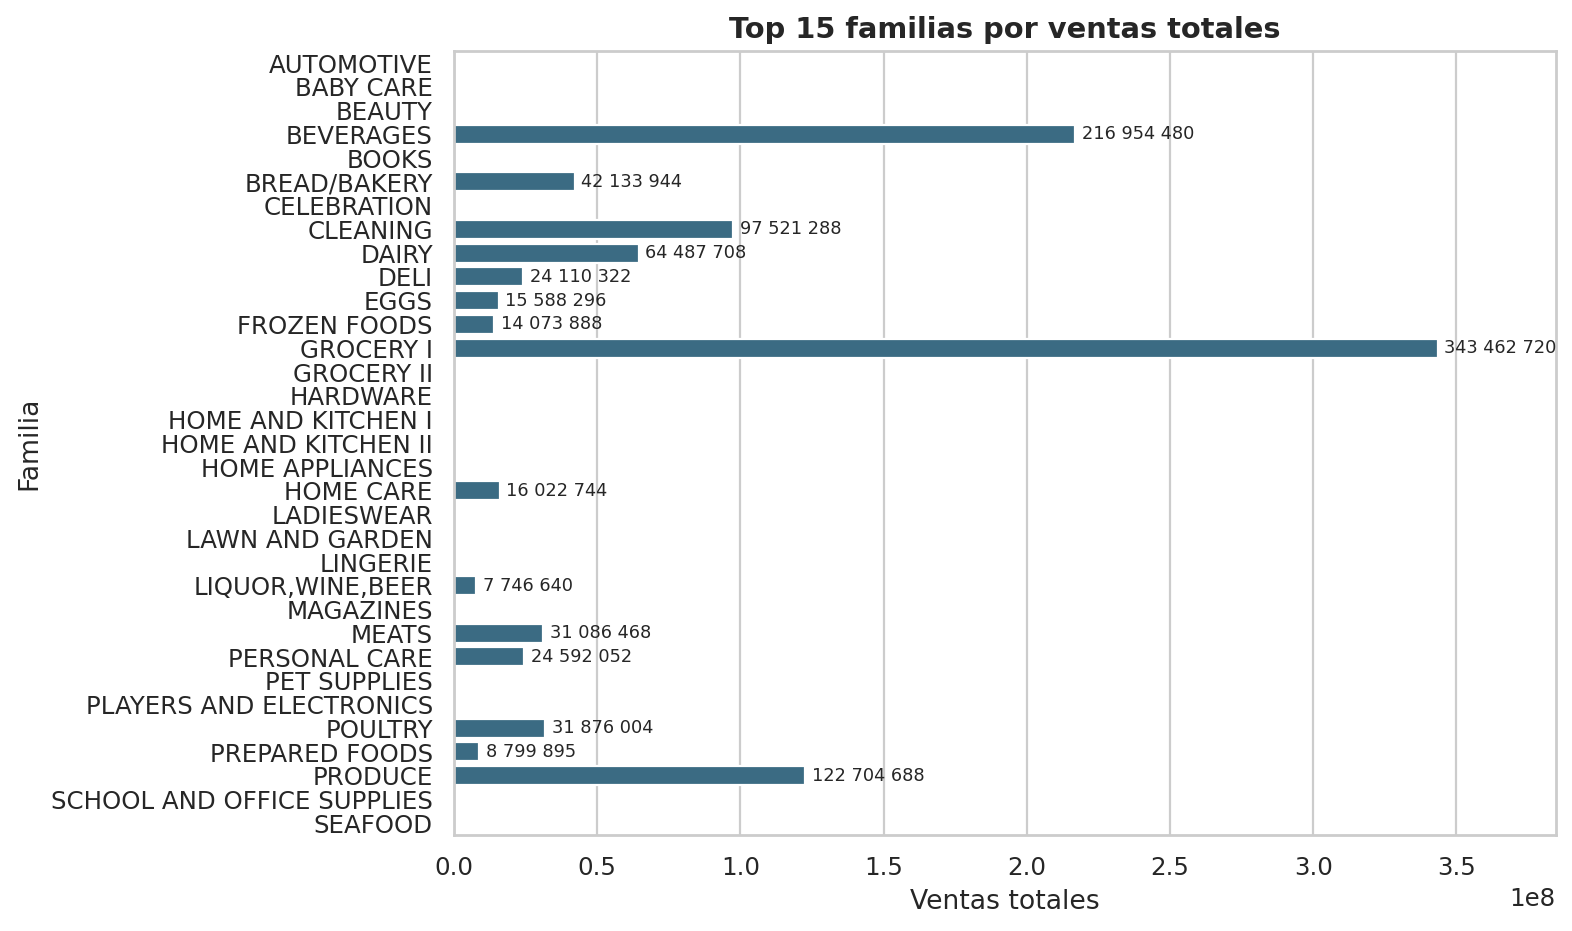

In [8]:
display(Image(filename=str(figures / '06_top_familias_ventas.png'), width=700))

### Interpretacion - Familias de Producto
- **GROCERY I** y **BEVERAGES** dominan con >50% de las ventas totales combinadas.
- Existe enorme disparidad: la familia top vende 53,000x mas que la ultima (BOOKS).
- El % de ceros varia entre familias: PRODUCE tiene 28% vs GROCERY I con 8%, indicando patrones de demanda diferenciados.
- El coeficiente de variacion tambien difiere: PRODUCE (1.62) es mas volatil que CLEANING (0.69).

> **Implicacion:** Los modelos deben considerar la familia como variable segmentadora clave.

---
## 5. Analisis Univariado

Se examinan las distribuciones individuales de variables categoricas y numericas.

In [9]:
print("=== Variables categoricas ===")
display(pd.read_csv(processed / 'univariado_categoricas.csv'))
print()
print("=== Variables numericas ===")
display(pd.read_csv(processed / 'univariado_numericas.csv'))

=== Variables categoricas ===


,variable,cardinalidad,valor_mas_frecuente,frecuencia_maxima
0,family,33,AUTOMOTIVE,90936
1,store_nbr,54,1,55572
2,city,22,Quito,18
3,state,16,Pichincha,19
4,type,5,D,18
5,cluster,17,3,7



=== Variables numericas ===


,variable,conteo,nulos,media,mediana,desv_std,asimetria,min,p25,p75,max
0,onpromotion_train,3000888,0,2.6028,0.0000,12.2189,11.1666,0.0000,0.0000,0.0000,741.0000
1,transactions,83488,0,"1,694.6022","1,393.0000",963.2866,1.5183,5.0000,"1,046.0000","2,079.0000","8,359.0000"
2,dcoilwtico,1175,43,67.7144,53.1900,25.6305,0.3212,26.1900,46.4050,95.6600,110.6200


### Interpretacion
**Categoricas:**
- **family:** 33 categorias, distribucion uniforme (cada familia tiene exactamente las mismas filas por tienda-dia).
- **store_nbr:** 54 tiendas con distribucion uniforme.
- **city:** 22 ciudades; Quito concentra la mayor cantidad de tiendas (18 de 54).
- **type:** 5 tipos de tienda; D es el mas comun (18 tiendas).
- **cluster:** 17 clusters comerciales; el cluster 3 es el mas poblado.

**Numericas:**
- **onpromotion:** Mediana = 0 (la mayoria de filas no tienen articulos en promocion). Fuertemente sesgada (asimetria = 11.2).
- **transactions:** Media = 1,695; CV moderado. Refleja flujo de clientes.
- **dcoilwtico:** Precio del petroleo entre $26-$111. Solo 43 nulos originales.

> **Conclusion:** Las variables categoricas son limpias y balanceadas. Las numericas presentan asimetria positiva tipica de datos de retail.

---
## 6. Analisis Temporal

Se examina la tendencia, estacionalidad y efectos de calendario sobre las ventas.

### 6.1 Tendencia de Ventas Diarias

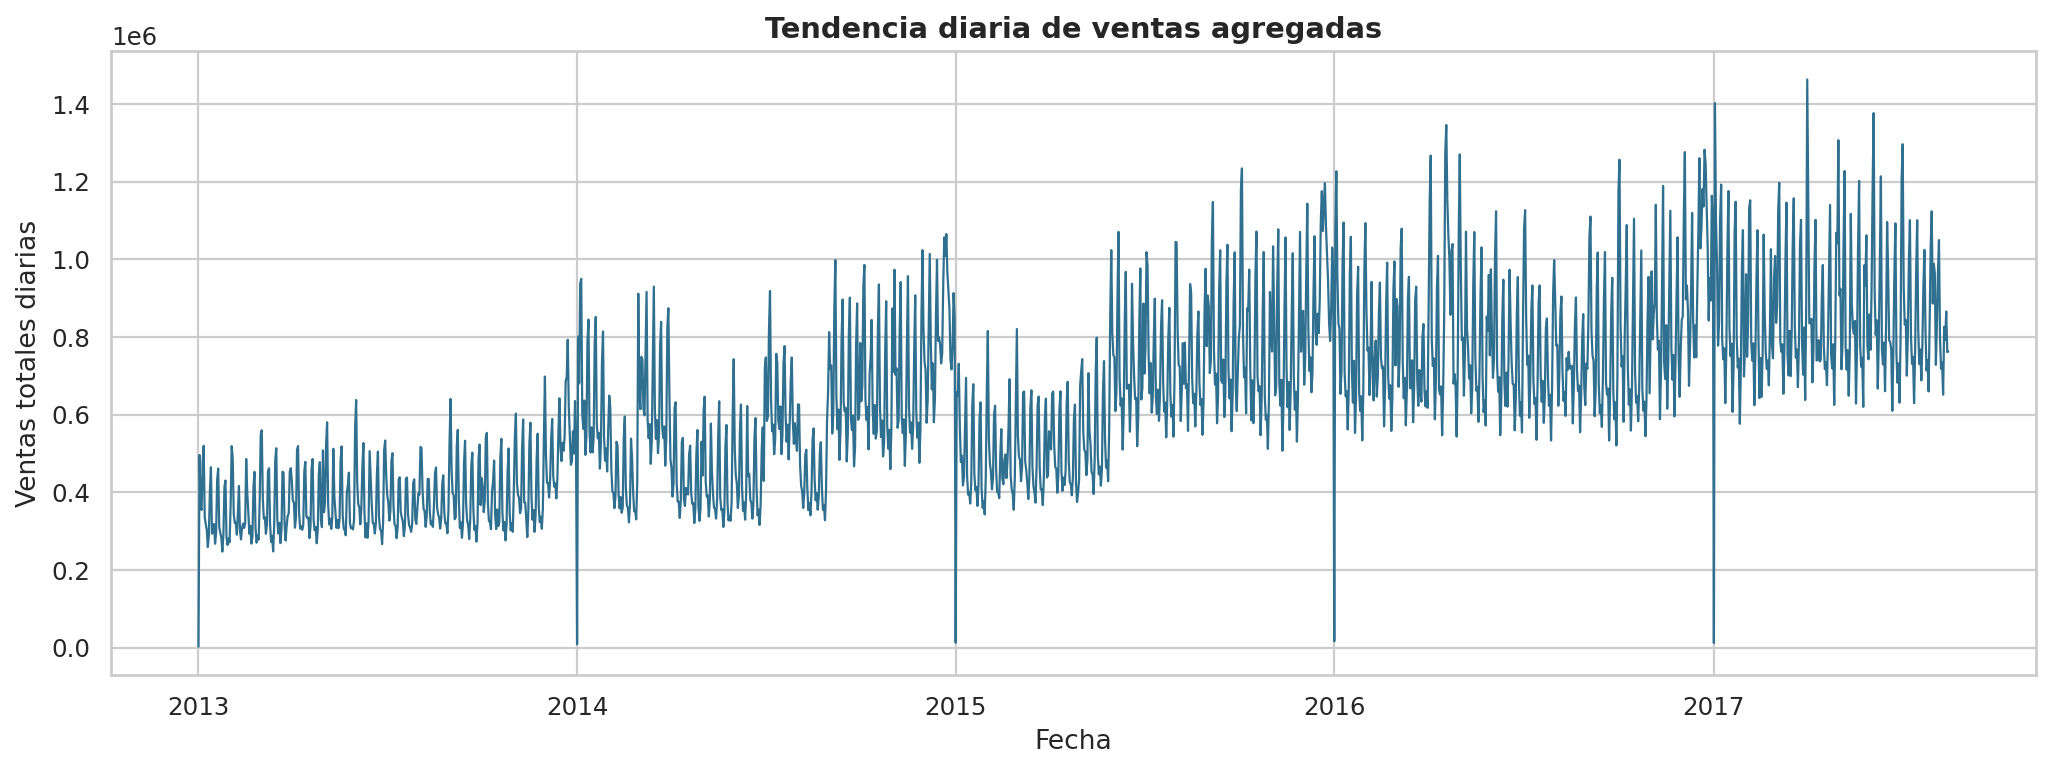

In [10]:
display(Image(filename=str(figures / '03_tendencia_ventas_diarias.png'), width=800))

### Interpretacion - Tendencia
- **Tendencia creciente** sostenida de 2013 a 2017 (ventas diarias medias crecieron de 385K a 855K).
- **Volatilidad alta** con picos pronunciados en diciembre y caidas en enero.
- Se observa un **quiebre en abril 2016** (terremoto de Ecuador) con pico anomalo seguido de caida.
- La estacionalidad intra-anual es clara y repetitiva.

> **Implicacion:** Los modelos necesitan capturar tanto la tendencia como la estacionalidad.

### 6.2 Estacionalidad Anual (Year-over-Year)

In [11]:
print("=== Ventas anuales ===")
display(pd.read_csv(processed / 'ventas_anuales.csv'))

=== Ventas anuales ===


,year,dias_observados,ventas_total,venta_media_diaria,anio_completo,yoy_media_diaria_pct
0,2013,364,"140,419,000.0000","385,766.5000",True,NaN
1,2014,364,"209,474,240.0000","575,478.7000",True,49.1780
2,2015,364,"240,880,100.0000","661,758.5000",True,14.9927
3,2016,365,"288,654,530.0000","790,834.3000",True,19.5050
4,2017,227,"194,217,070.0000","855,581.8000",False,8.1872


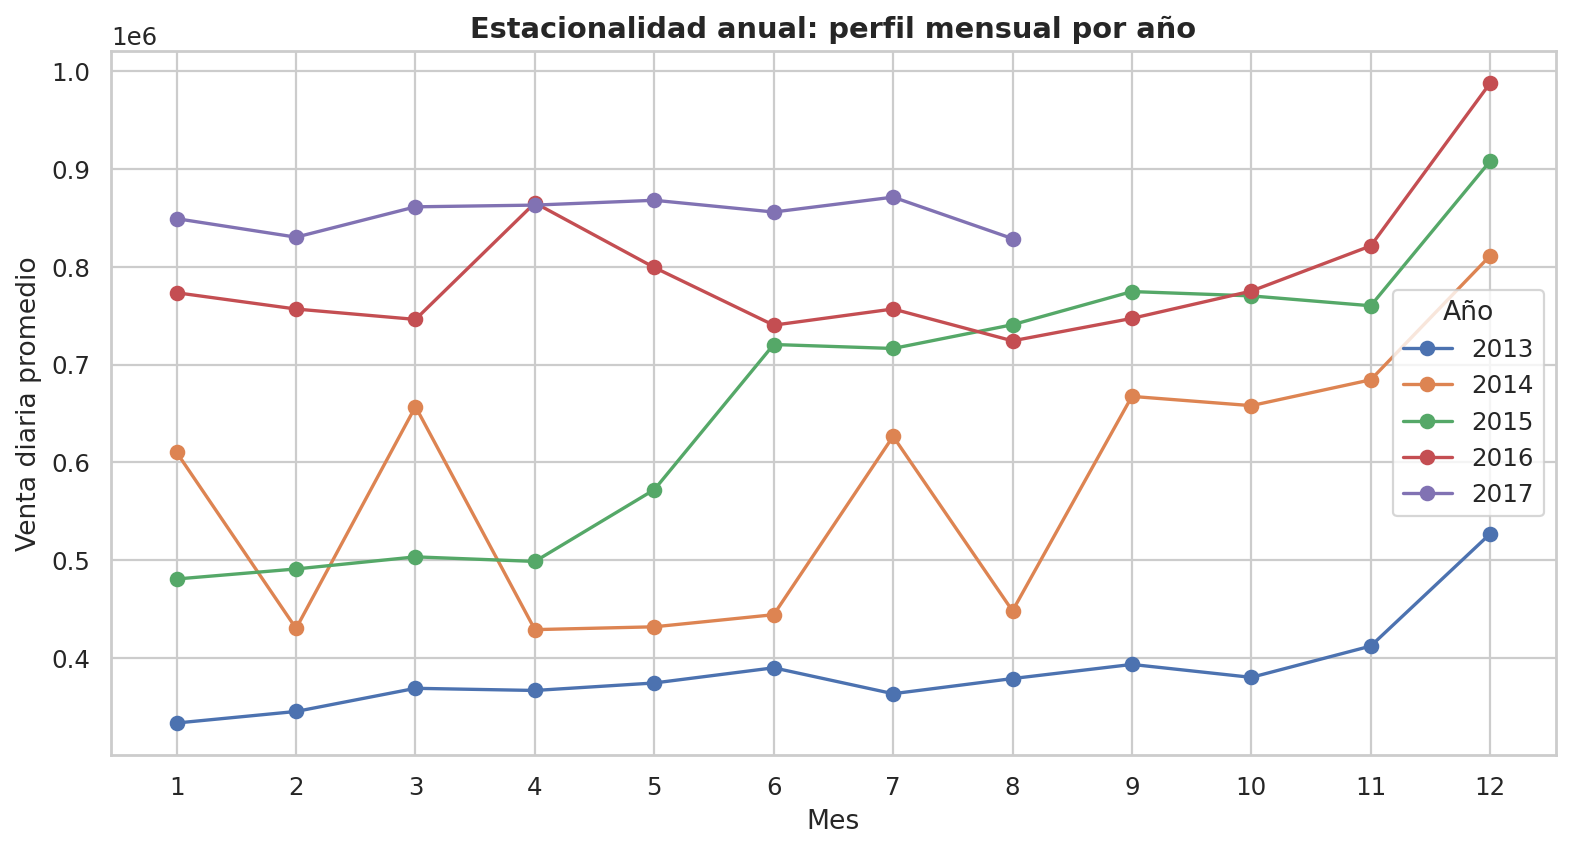

In [12]:
display(Image(filename=str(figures / '13_estacionalidad_anual.png'), width=800))

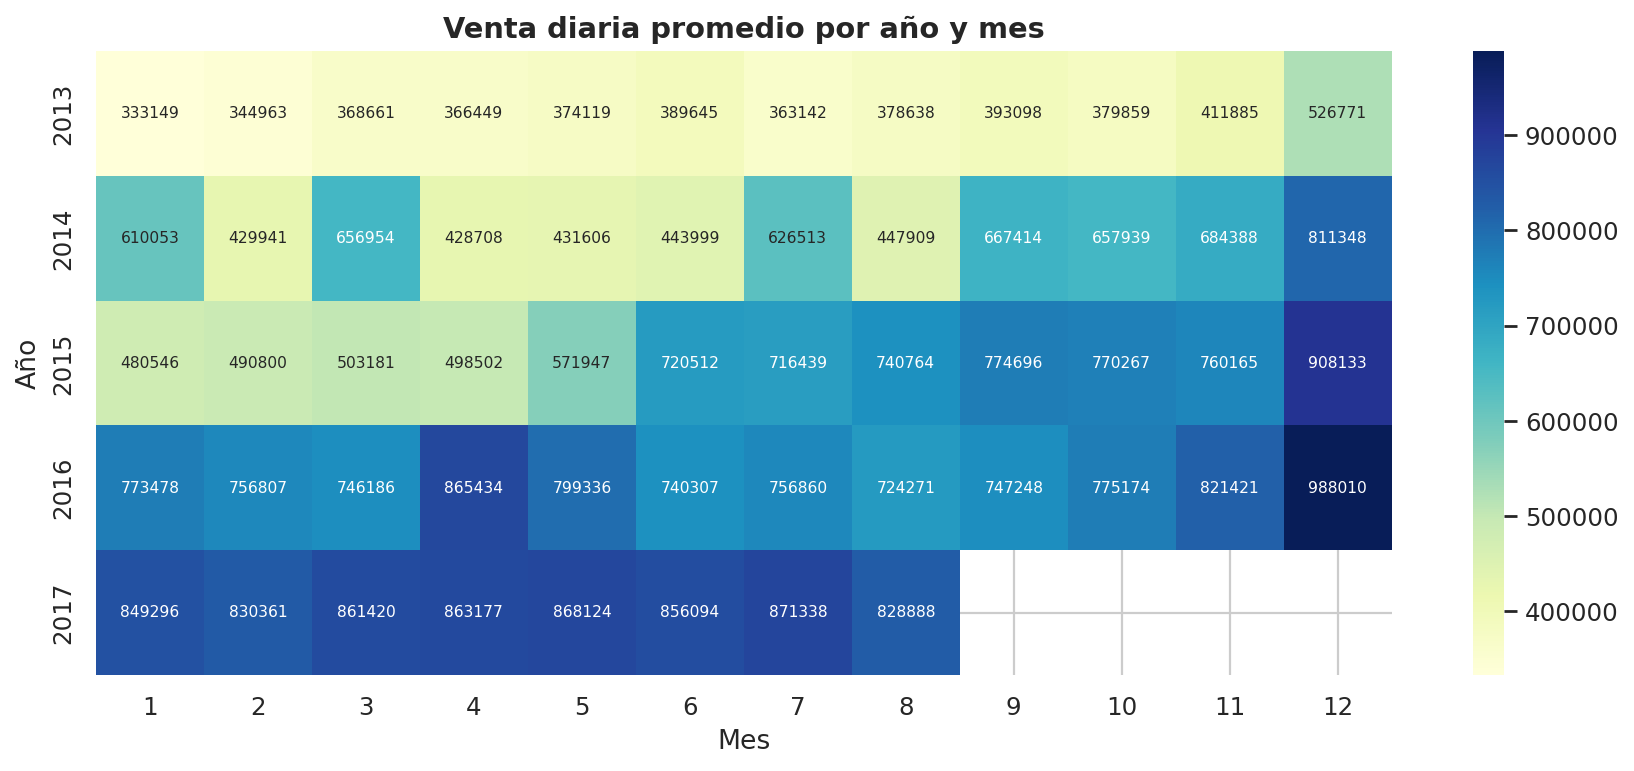

In [13]:
display(Image(filename=str(figures / '14_heatmap_anio_mes.png'), width=800))

### Interpretacion - Estacionalidad Anual
- **Crecimiento consistente:** YoY de +49% (2014), +15% (2015), +20% (2016), +8% (2017 parcial).
- El **perfil mensual se repite** cada ano con el mismo patron: picos en nov-dic, valle en feb.
- El heatmap muestra que el crecimiento es **uniforme entre meses** (toda la curva sube, no solo algunos meses).
- 2017 es parcial (enero-agosto), por lo que su total anual no es comparable.

> **Decision:** Usar variables `year` y `month` como predictoras; la tendencia aporta senal significativa.

### 6.3 Indice Estacional Mensual

In [14]:
print("=== Indice estacional mensual (1.0 = nivel tipico del anio) ===")
display(pd.read_csv(processed / 'indice_estacional_mes.csv'))

=== Indice estacional mensual (1.0 = nivel tipico del anio) ===


,month,indice_estacional,anios_observados
0,1,0.9241,5
1,2,0.8621,5
2,3,0.9616,5
3,4,0.9103,5
4,5,0.9219,5
5,6,0.9614,5
6,7,1.0176,5
7,8,0.9528,5
8,9,1.0736,4
9,10,1.0680,4


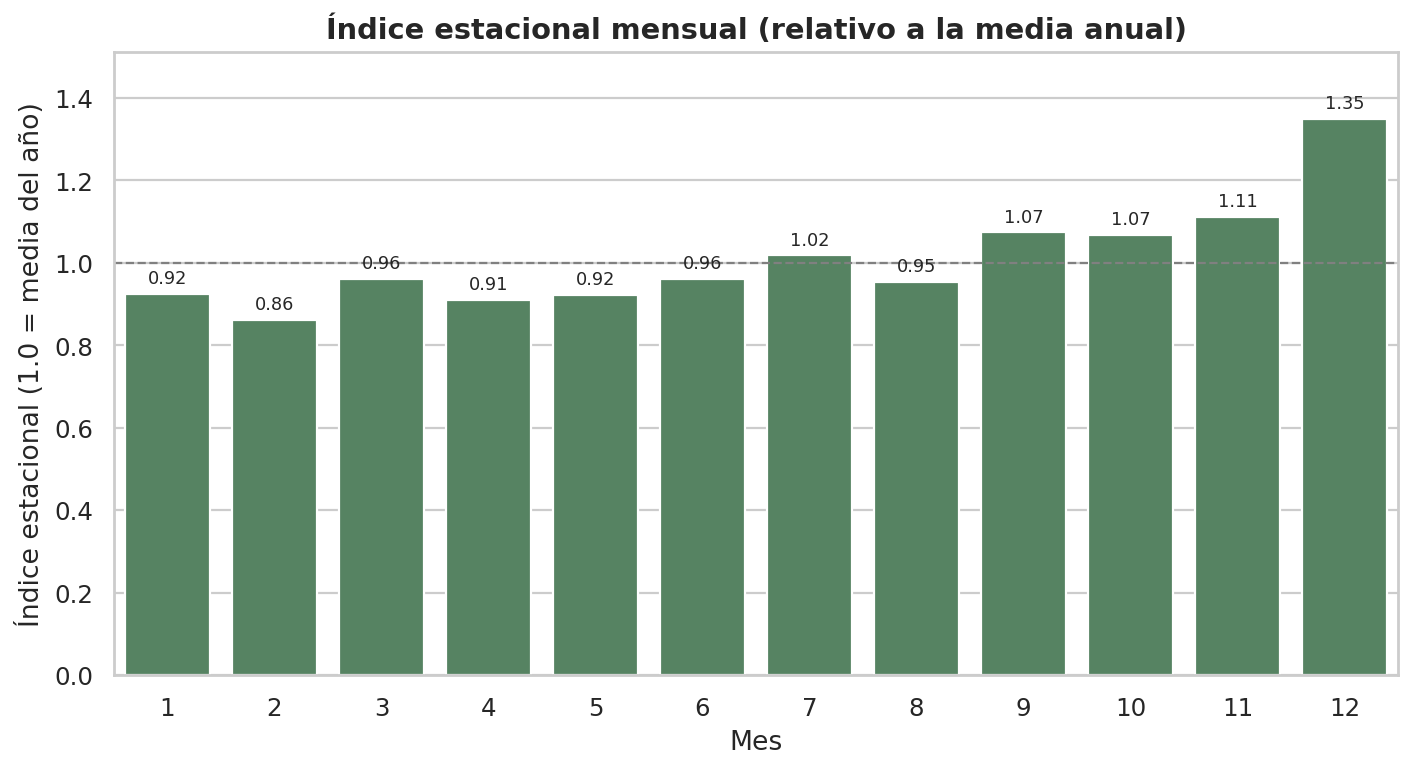

In [15]:
display(Image(filename=str(figures / '04_estacionalidad_mensual.png'), width=700))

### Interpretacion - Estacionalidad Mensual
- **Diciembre** es el mes pico con indice **1.35** (35% por encima de la media anual).
- **Noviembre** (1.11), **septiembre** (1.07) y **octubre** (1.07) tambien estan por encima.
- **Febrero** es el valle mas profundo con indice **0.86** (14% por debajo de la media).
- El patron es coherente con el ciclo comercial: fiestas navidenas, regreso a clases, Dia de la Madre.

> **Implicacion:** La variable `month` tiene fuerte poder predictivo. Considerar features ciclicas (sin/cos).

### 6.4 Estacionalidad por Dia de Semana

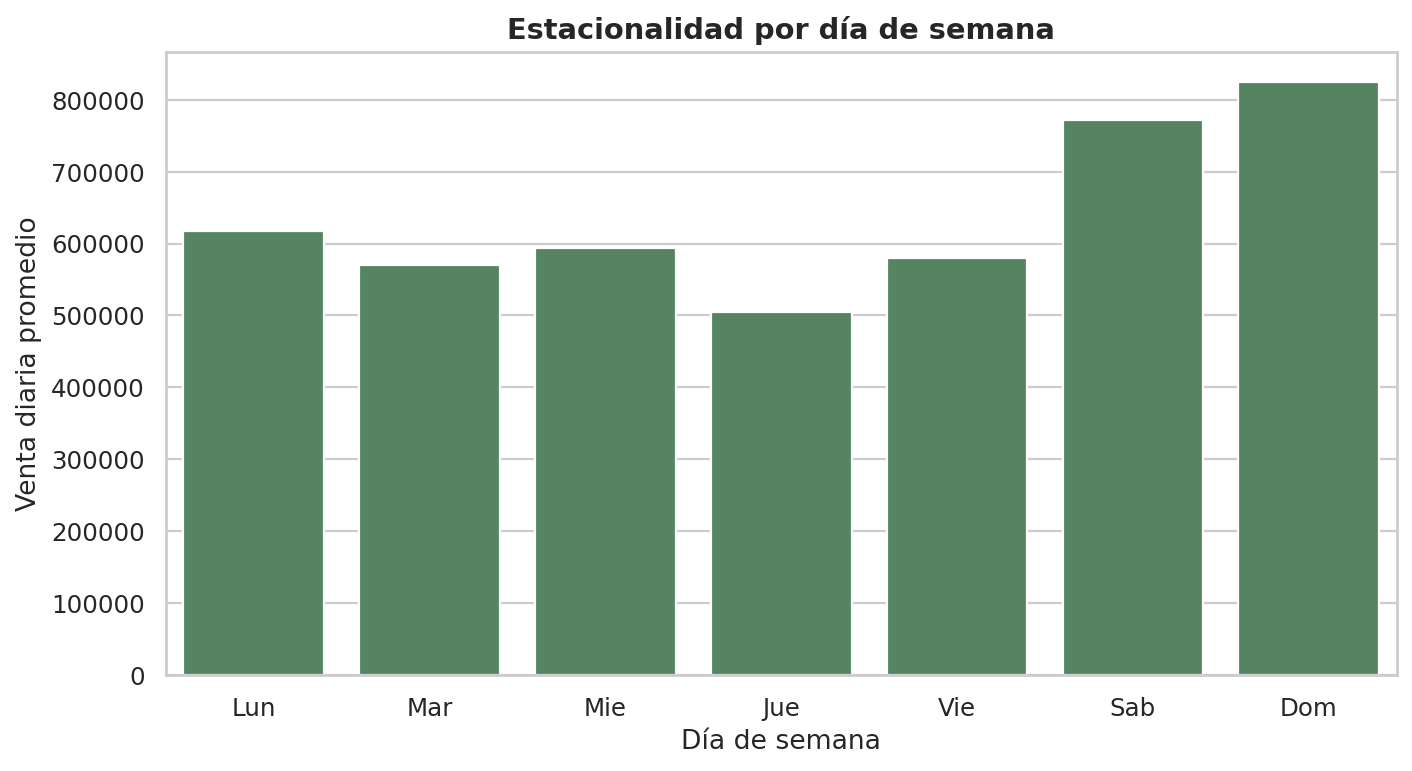

In [16]:
display(Image(filename=str(figures / '05_estacionalidad_dia_semana.png'), width=700))

### Interpretacion - Dia de Semana
- **Domingo** y **sabado** son los dias de mayor venta (fin de semana de compras).
- **Jueves** tiende a ser el dia mas bajo entre semana.
- La variable `dayofweek` y la bandera `is_weekend` capturan este efecto.

> **Implicacion:** Incluir `dayofweek` e `is_weekend` como predictoras.

### 6.5 Efecto de Feriados y Eventos

In [17]:
print("=== Efecto por tipo de feriado ===")
display(pd.read_csv(processed / 'efecto_tipo_feriado.csv'))

=== Efecto por tipo de feriado ===


,type,dias,venta_media_diaria,venta_mediana_diaria
0,Additional,29,"929,776.6875","1,008,143.3750"
1,Transfer,7,"845,275.3125","826,373.7500"
2,Bridge,3,"796,110.0000","858,468.1875"
3,Event,55,"757,393.5000","737,819.5000"
4,Work Day,5,"663,184.6875","569,956.9375"
5,Sin feriado nacional,1548,"627,918.1250","624,754.3750"
6,Holiday,40,"614,994.4375","623,748.5938"


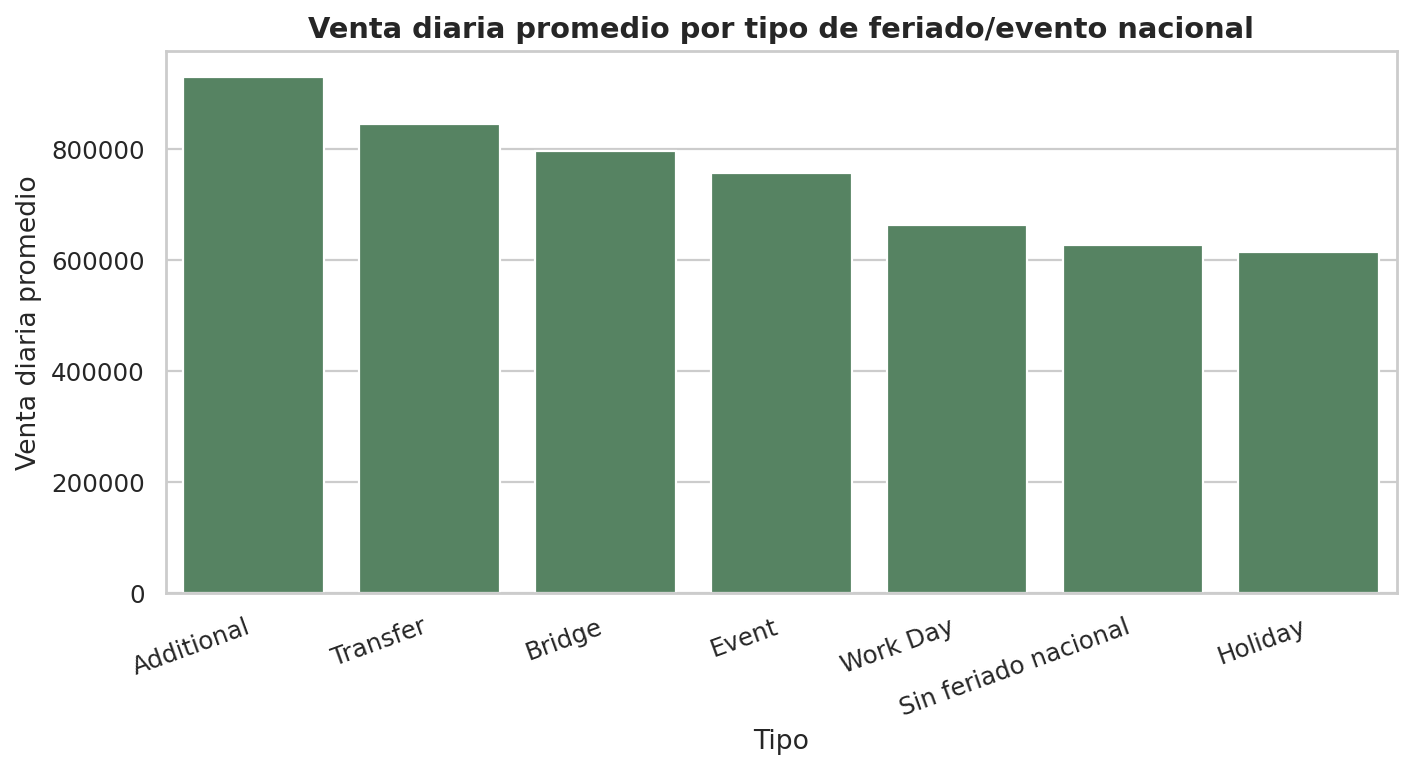

In [18]:
display(Image(filename=str(figures / '15_efecto_tipo_feriado.png'), width=700))

### Interpretacion - Feriados
- Los **"Additional"** (feriados adicionales decretados, como post-terremoto 2016) generan el mayor pico: venta diaria promedio 48% superior al dia normal.
- Los **"Transfer"** (feriados trasladados) y **"Bridge"** (puentes) tambien superan la media.
- Los **"Holiday"** regulares son sorprendentemente neutros (similar al dia sin feriado), posiblemente por cierre parcial de tiendas.
- Los **"Work Day"** (dias laborales de compensacion) estan por encima del promedio.

> **Decision:** Las banderas `holiday_national`, `holiday_any` y el tipo de evento son predictoras valiosas.

### 6.6 Dias Pico de Ventas

In [19]:
print("=== Top 10 dias con mayores ventas ===")
display(pd.read_csv(processed / 'dias_pico_ventas.csv'))

=== Top 10 dias con mayores ventas ===


,date,sales_total
0,2017-04-01,"1,463,084.0000"
1,2017-01-02,"1,402,306.4000"
2,2017-06-04,"1,376,511.5000"
3,2016-04-18,"1,345,920.6000"
4,2017-05-01,"1,306,699.4000"
5,2017-07-02,"1,296,379.2000"
6,2016-12-23,"1,282,145.5000"
7,2016-12-04,"1,276,195.0000"
8,2016-04-17,"1,271,833.8000"
9,2016-05-01,"1,270,121.2000"


### Interpretacion
- Los picos coinciden con: inicios de mes (efecto quincena/sueldo), feriados nacionales y eventos como Dia de la Madre, Navidad.
- El **1 de abril 2017** es el dia record, asociado al periodo posterior al terremoto de 2016 (acopio masivo).
- La concentracion de picos en 2016-2017 refleja tanto el crecimiento tendencial como eventos especificos.

---
## 7. Integracion de Fuentes

Se construye el dataset analitico unificado combinando las 7 fuentes originales.

In [20]:
print("=== Resultado de integracion ===")
integracion = _json.loads((processed / 'resumen_integracion.json').read_text())
for k, v in integracion.items():
    print(f"  {k}: {v}")
print()
print("=== Catalogo de columnas del dataset integrado ===")
display(pd.read_csv(processed / 'catalogo_columnas.csv'))

=== Resultado de integracion ===
  filas: 3000888
  columnas: 30
  transactions_missing_rows: 245784
  transactions_missing_pct: 8.1903756488
  oil_original_missing_dates_after_reindex: 525
  oil_missing_after_fill: 0
  holiday_any_rows: 254760
  holiday_any_pct: 8.4894871118
  n_predictoras: 27

=== Catalogo de columnas del dataset integrado ===


,columna,tipo,origen,descripcion
0,id,int32,train,Identificador unico de fila
1,date,datetime64[us],train,Fecha de la observacion
2,store_nbr,int16,train,Numero de tienda
3,family,category,train,Familia de producto
4,sales,float32,train,OBJETIVO: ventas (unidades) tienda-familia-dia
5,onpromotion,int16,train,Articulos de la familia en promocion ese dia
6,city,str,stores,Ciudad de la tienda
7,state,str,stores,Provincia/estado de la tienda
8,type,category,stores,Tipo de tienda (A-E)
9,cluster,int16,stores,Cluster comercial original de la tienda


### Interpretacion - Integracion
**Decisiones de integracion:**
1. `train` + `stores` por `store_nbr` (muchos-a-uno validado).
2. `transactions` por `date` + `store_nbr`; faltantes marcados con bandera `transactions_missing`.
3. `oil` reindexado al calendario de train; imputado con forward-fill/backward-fill.
4. `holidays_events` desagregado por alcance (nacional/regional/local); transferidos excluidos.

**Resultado:** Dataset de **3,000,888 filas x 30 columnas** (27 predictoras potenciales).
- 8.19% de filas con transacciones faltantes (dias sin dato, marcados).
- 0% de petroleo faltante despues del relleno temporal.
- 8.49% de filas con algun feriado/evento activo.

> **Conclusion:** La integracion es completa y trazable. Cada imputacion queda documentada con banderas booleanas.

---
## 8. Analisis Bivariado y Correlaciones

Se evaluan las relaciones entre variables predictoras y el objetivo `sales`.

### 8.1 Efecto de Promociones

In [21]:
print("=== Ventas con y sin promocion ===")
display(pd.read_csv(processed / 'relacional_promo_flag.csv'))

=== Ventas con y sin promocion ===


,en_promo,filas,media_sales,mediana_sales
0,Sin promo,2389559,158.2467,3.0000
1,Con promo,611329,"1,137.6937",373.0000


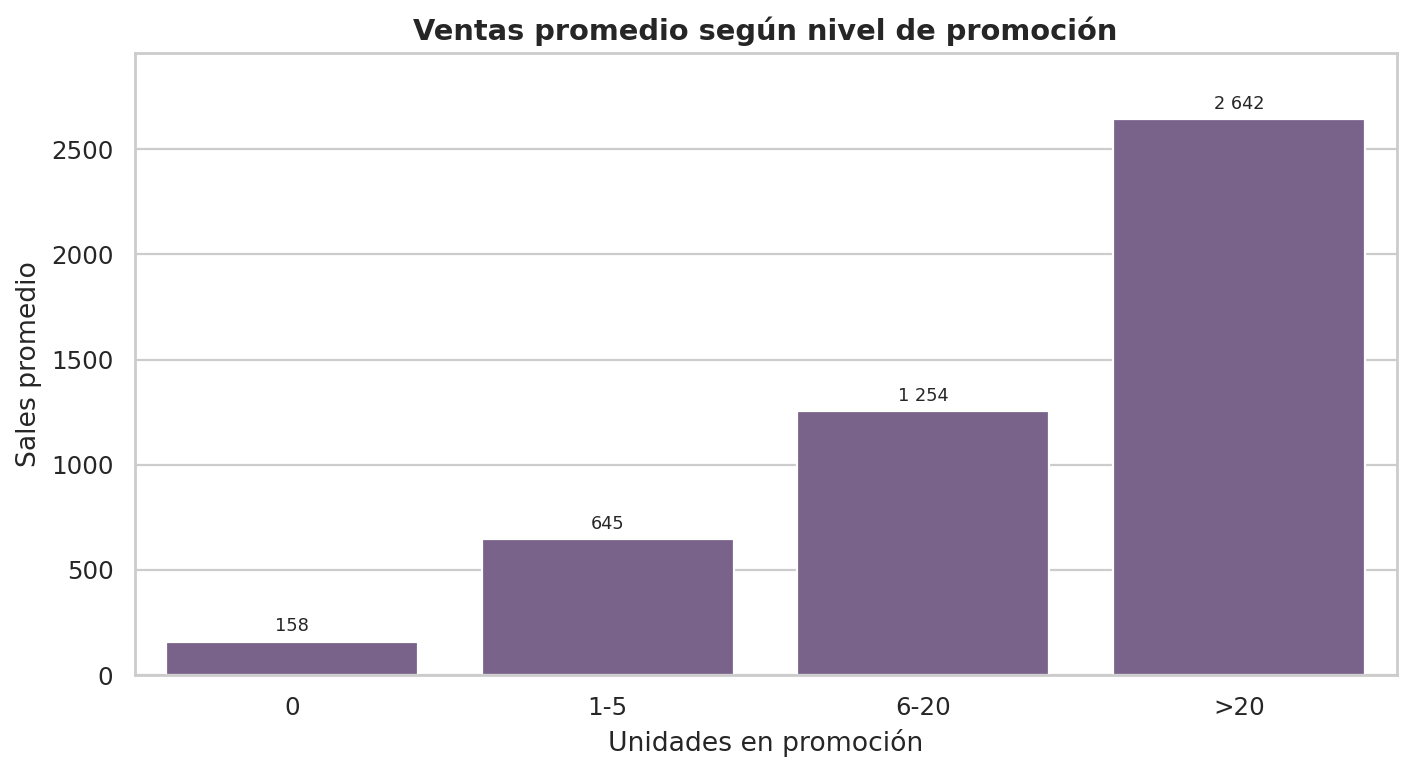

In [22]:
display(Image(filename=str(figures / '07_promocion_vs_sales.png'), width=700))

### Interpretacion - Promociones
- Las filas **con promocion** tienen ventas promedio **7.2x mayores** que sin promocion (1,138 vs 158).
- La mediana con promocion (373) es **124x la mediana sin promocion** (3.0).
- La relacion es monotona: a mayor cantidad de articulos en promo, mayor venta media.
- `onpromotion` es la **variable con mayor correlacion lineal** con sales (r = 0.43).

> **Implicacion:** `onpromotion` es el predictor mas importante. Su ausencia en la mayoria de filas (mediana=0) sugiere que modelos de arbol la captaran mejor que lineales.

### 8.2 Transacciones vs Ventas

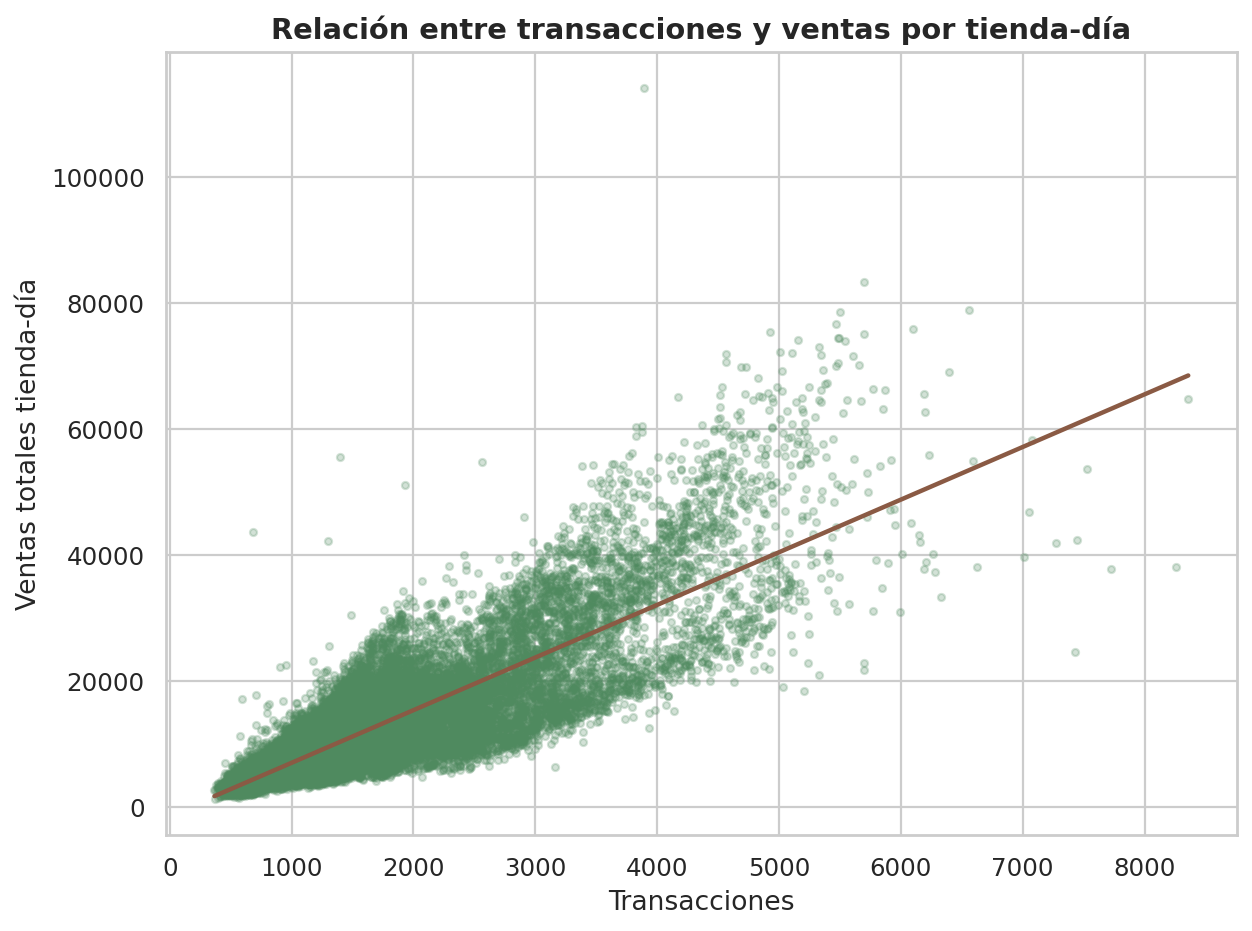

In [23]:
display(Image(filename=str(figures / '08_transacciones_vs_sales.png'), width=700))

### Interpretacion - Transacciones
- Relacion **positiva fuerte** entre transacciones y ventas a nivel tienda-dia.
- La linea de regresion muestra tendencia lineal clara.
- `transactions_filled` es el **segundo predictor mas correlacionado** (r = 0.23).
- Nota: en produccion (test), esta variable puede no estar disponible en tiempo real.

> **Implicacion:** Usar transacciones como feature si se dispone del dato; alternativamente usar rezagos.

### 8.3 Precio del Petroleo vs Ventas

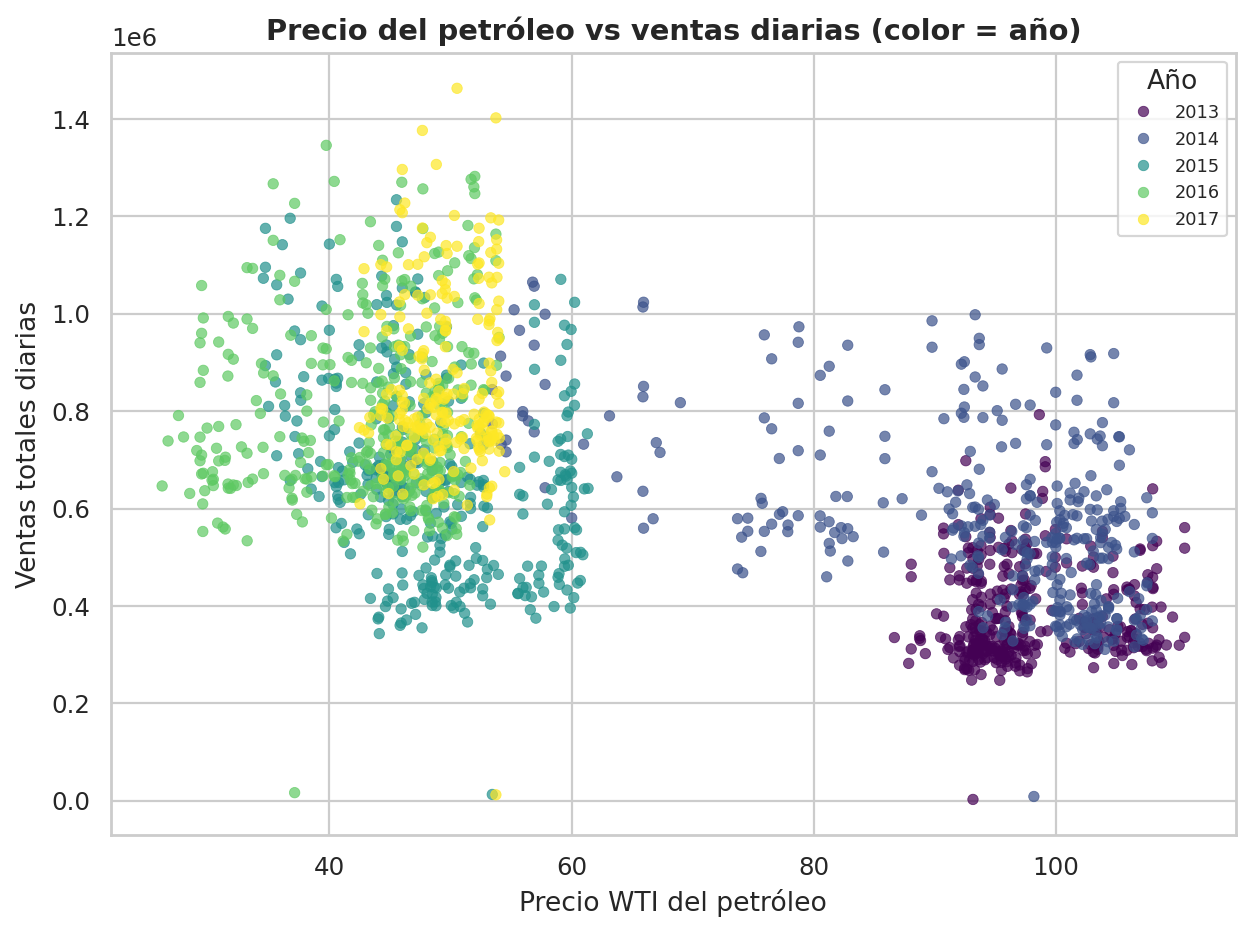

In [24]:
display(Image(filename=str(figures / '09_petroleo_vs_sales.png'), width=700))

### Interpretacion - Petroleo
- La correlacion global petroleo-ventas es **negativa (r = -0.07)** pero es **espuria**.
- Al colorear por ano se revela que: el petroleo **bajo** de 2014 a 2016 mientras las ventas **subieron** (tendencia temporal opuesta).
- Dentro de cada ano, la relacion es debil o inexistente.
- Ecuador exporta petroleo, asi que un precio alto deberia **estimular** la economia, pero el efecto es indirecto.

> **Decision:** Incluir `dcoilwtico` como variable contexto, pero su senal predictiva directa es baja. Posible uso en interacciones o como proxy macro.

### 8.4 Ventas por Tipo de Tienda y Cluster

In [25]:
print("=== Ventas por tipo de tienda ===")
display(pd.read_csv(processed / 'relacional_type_sales.csv'))

=== Ventas por tipo de tienda ===


,type,filas,ventas_total,media_sales,mediana_sales
0,A,500148,"353,043,840.0000",705.8787,24.0000
1,D,1000296,"351,083,300.0000",350.9794,16.0000
2,C,833580,"164,434,740.0000",197.2633,5.0000
3,B,444576,"145,260,640.0000",326.7397,7.0000
4,E,222288,"59,822,436.0000",269.1213,4.0000


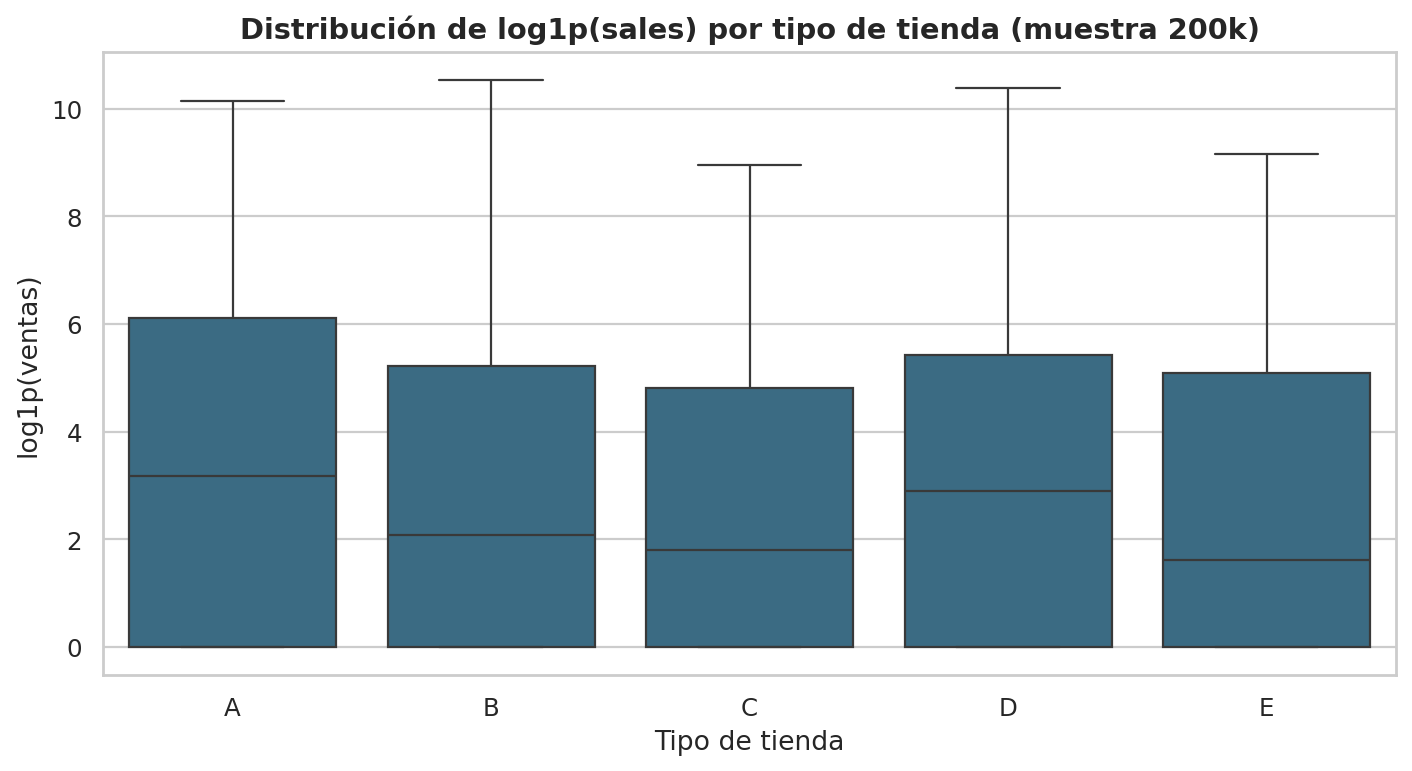

In [26]:
display(Image(filename=str(figures / '17_dist_log_sales_por_tipo.png'), width=700))

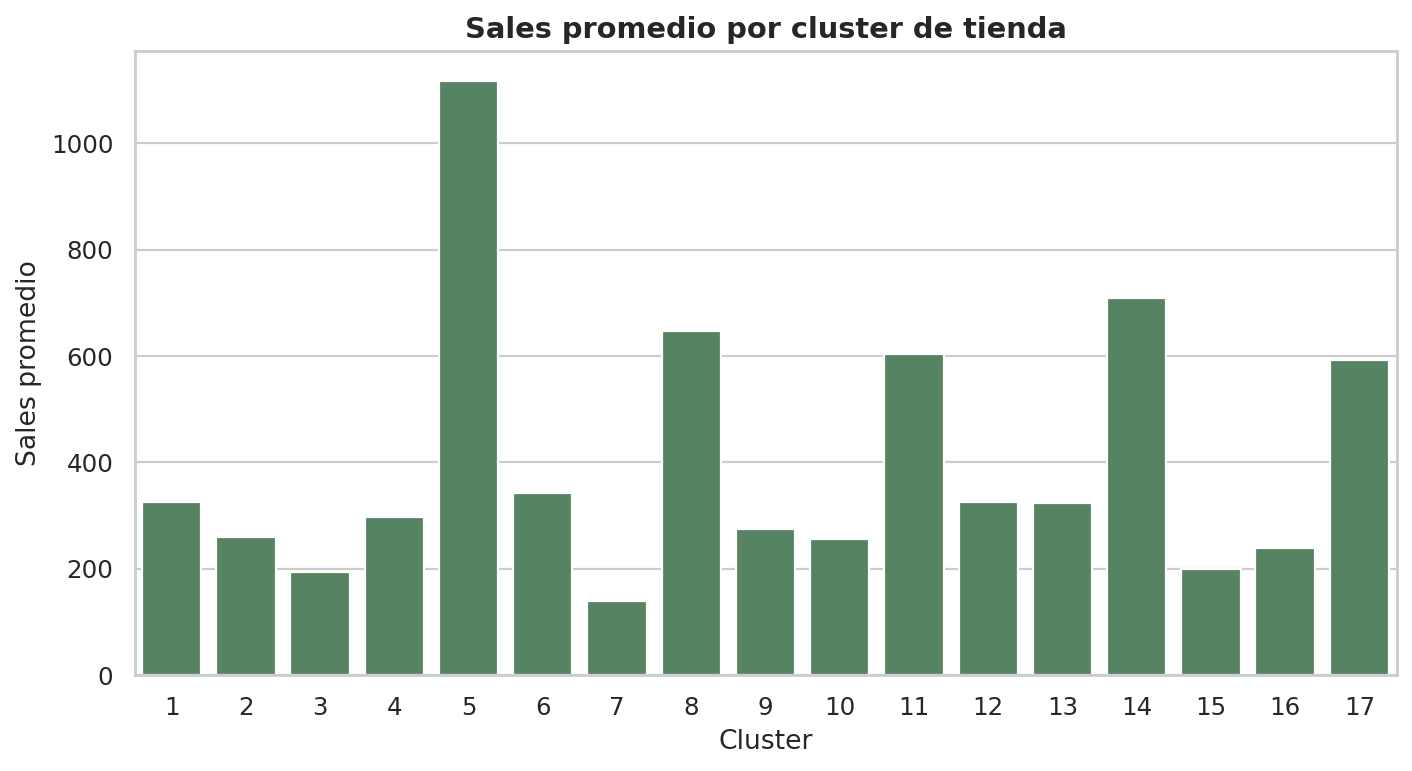

In [27]:
display(Image(filename=str(figures / '12_sales_promedio_cluster.png'), width=700))

### Interpretacion - Tipo y Cluster
- Las tiendas **tipo A** tienen la mayor venta media (706), seguidas de D (351) y B (327).
- Los **clusters** muestran heterogeneidad significativa: el cluster 5 vende 4x mas que el cluster 3.
- El boxplot por tipo revela distribuciones diferenciadas (A tiene mayor mediana y rango intercuartil).

> **Implicacion:** Tanto `type` como `cluster` son features segmentadoras utiles para el modelado.

### 8.5 Matriz de Correlaciones

In [28]:
print("=== Correlaciones numericas ===")
display(pd.read_csv(processed / 'correlaciones_numericas.csv', index_col=0))

=== Correlaciones numericas ===


,sales,onpromotion,transactions_filled,dcoilwtico,holiday_event_count,holiday_national,holiday_regional,holiday_local,is_payday,is_weekend,is_month_end,year,month,day,dayofweek,cluster
sales,1.0000,0.4279,0.2331,-0.0748,0.0177,0.0174,-0.0021,0.0038,0.0011,0.0519,0.0031,0.0811,0.0198,-0.0119,0.0369,0.0385
onpromotion,0.4279,1.0000,0.0511,-0.1546,0.0185,0.0187,-0.0001,0.0014,0.0026,-0.0296,0.0023,0.1991,0.0259,0.0022,-0.0027,0.0057
transactions_filled,0.2331,0.0511,1.0000,-0.0516,0.0502,0.0506,-0.0102,0.0066,0.0081,0.1151,0.0128,0.0456,0.0469,-0.0072,0.0861,0.1874
dcoilwtico,-0.0748,-0.1546,-0.0516,1.0000,-0.0408,-0.0412,-0.0010,-0.0026,-0.0021,0.0012,0.0007,-0.8342,0.0107,-0.0020,0.0030,-0.0000
holiday_event_count,0.0177,0.0185,0.0502,-0.0408,1.0000,0.9729,0.0598,0.2126,0.0031,0.0282,0.0365,0.0257,0.0606,-0.0288,0.0248,0.0022
holiday_national,0.0174,0.0187,0.0506,-0.0412,0.9729,1.0000,-0.0033,-0.0099,0.0065,0.0278,0.0402,0.0274,0.0499,-0.0240,0.0234,-0.0000
holiday_regional,-0.0021,-0.0001,-0.0102,-0.0010,0.0598,-0.0033,1.0000,-0.0012,-0.0049,-0.0011,-0.0034,-0.0013,0.0094,-0.0169,0.0015,0.0023
holiday_local,0.0038,0.0014,0.0066,-0.0026,0.2126,-0.0099,-0.0012,1.0000,-0.0132,0.0052,-0.0115,-0.0043,0.0511,-0.0194,0.0085,0.0090
is_payday,0.0011,0.0026,0.0081,-0.0021,0.0031,0.0065,-0.0049,-0.0132,1.0000,0.0016,0.6917,-0.0000,-0.0008,0.2117,-0.0008,0.0000
is_weekend,0.0519,-0.0296,0.1151,0.0012,0.0282,0.0278,-0.0011,0.0052,0.0016,1.0000,0.0021,-0.0000,-0.0008,0.0019,0.7907,0.0000


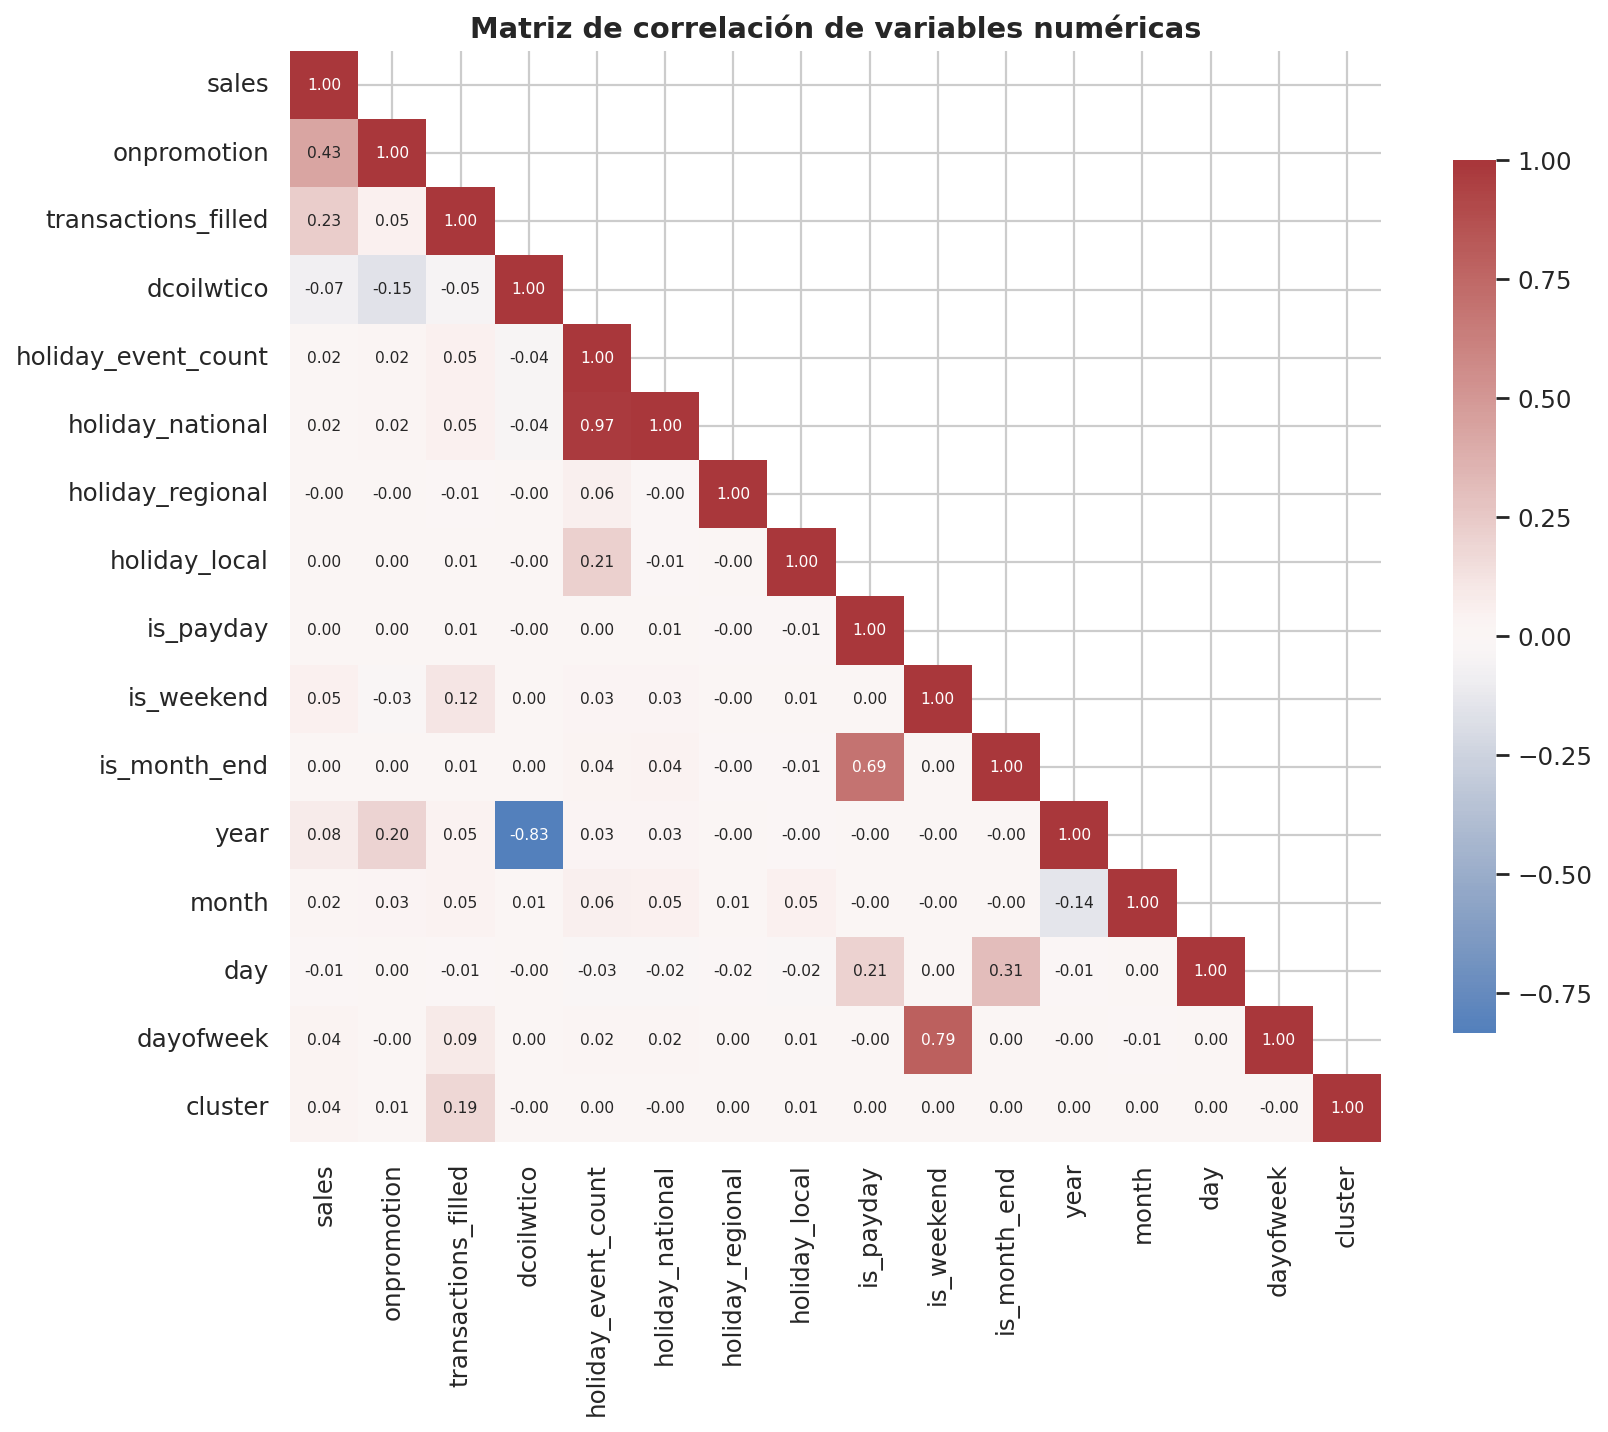

In [29]:
display(Image(filename=str(figures / '10_correlaciones_numericas.png'), width=750))

### Interpretacion - Correlaciones
- **onpromotion - sales:** r = 0.43 (la correlacion mas fuerte).
- **transactions_filled - sales:** r = 0.23.
- **year - sales:** r = 0.08 (captura la tendencia creciente).
- **dcoilwtico - sales:** r = -0.07 (espuria, ya explicado).
- **is_weekend - sales:** r = 0.05.
- No hay multicolinealidad critica entre predictoras (las correlaciones entre features son moderadas).

> **Conclusion:** Se identifican 2 predictoras fuertes (promo, transacciones) y varias moderadas (calendario, tipo, cluster).

### 8.6 Penetracion de Promociones en el Tiempo

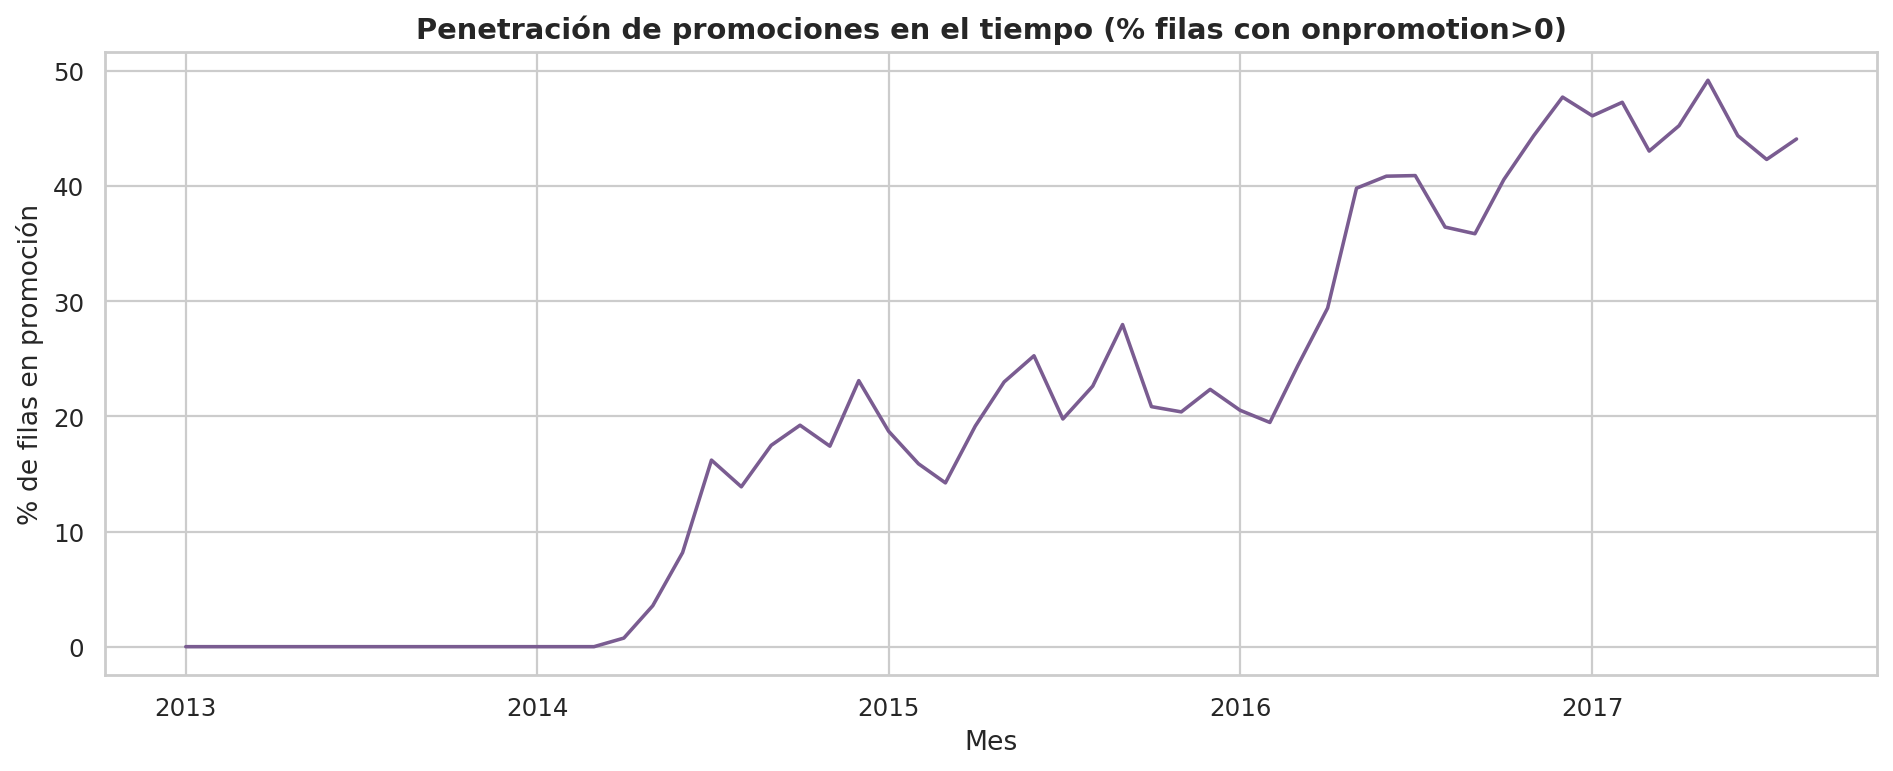

In [30]:
display(Image(filename=str(figures / '16_penetracion_promo_mensual.png'), width=800))

### Interpretacion
- La penetracion de promociones **aumento drasticamente** a partir de 2015 (de ~10% a ~40% de las filas).
- Esto indica un **cambio de estrategia comercial** en la cadena.
- Los modelos deben considerar que la relacion promo-ventas puede tener interaccion temporal.

### 8.7 Ranking de Senal Lineal

In [31]:
print("=== Senal lineal contra sales (correlacion) ===")
display(pd.read_csv(processed / 'senal_regresion.csv'))

=== Senal lineal contra sales (correlacion) ===


,variable,correlacion_sales,abs_corr
0,onpromotion,0.4279,0.4279
1,transactions_filled,0.2331,0.2331
2,year,0.0811,0.0811
3,dcoilwtico,-0.0748,0.0748
4,is_weekend,0.0519,0.0519
5,cluster,0.0385,0.0385
6,dayofweek,0.0369,0.0369
7,month,0.0198,0.0198
8,holiday_event_count,0.0177,0.0177
9,holiday_national,0.0174,0.0174


### Interpretacion
Las variables con mayor senal lineal para predecir `sales` son:
1. **onpromotion** (r=0.43) - senal comercial directa.
2. **transactions_filled** (r=0.23) - flujo de clientes.
3. **year** (r=0.08) - tendencia temporal.
4. **dcoilwtico** (r=-0.07) - variable macro (senal espuria).
5. **is_weekend** (r=0.05) - patron semanal.

> Nota: La correlacion lineal subestima relaciones no lineales. Modelos de arbol (XGBoost, LightGBM) pueden capturar interacciones no detectables aqui.

---
## 9. Aptitud para Clasificacion (Demanda Alta)

Se define un objetivo binario `demanda_alta = sales > P75(sales dentro de la familia)` para evaluar si la data soporta tareas de clasificacion.

In [32]:
print("=== Balance de clases (umbral por familia) ===")
display(pd.read_csv(processed / 'clasificacion_demanda_alta.csv'))
print()
print("=== Balance con umbral global (P75 = 195.85) ===")
display(pd.read_csv(processed / 'clasificacion_umbral_global.csv'))

=== Balance de clases (umbral por familia) ===


,demanda_alta,filas,pct
0,No,2329621,77.6311
1,Si,671267,22.3689



=== Balance con umbral global (P75 = 195.85) ===


,demanda_alta_global,filas,pct
0,No,2250666,75.0000
1,Si,750222,25.0000


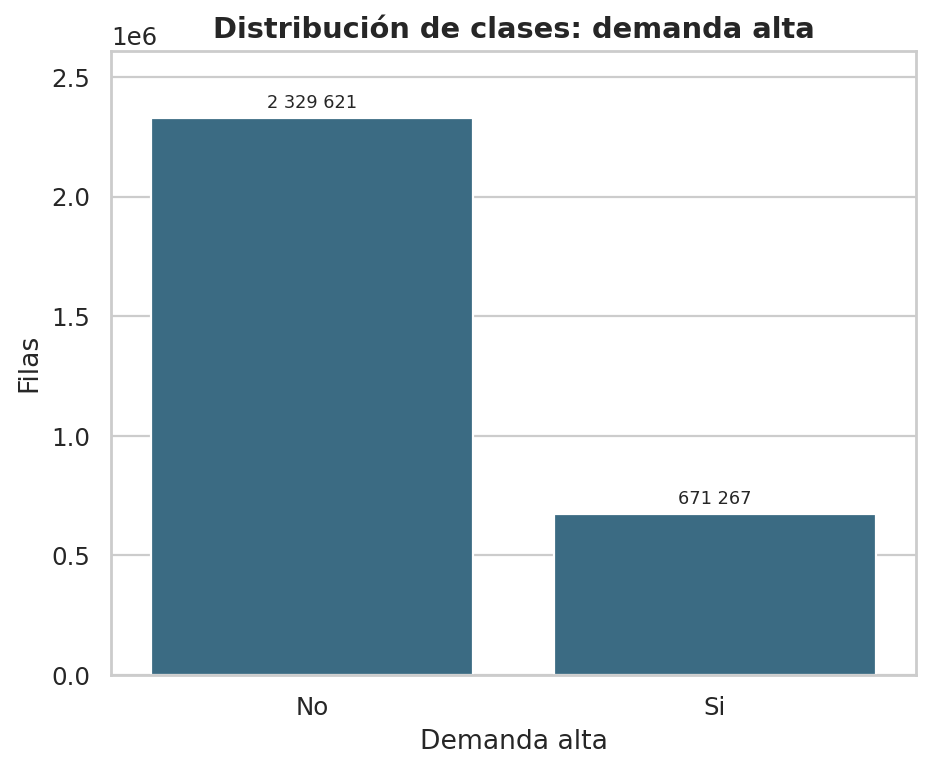

In [33]:
display(Image(filename=str(figures / '11_balance_clases_demanda.png'), width=600))

### Interpretacion - Clasificacion
- **Definicion por familia:** 77.6% clase negativa vs 22.4% positiva. Ratio de desbalance = **3.47:1**.
- **Definicion global:** 75.0% vs 25.0%. Ratio = 3:1.
- Ambas definiciones presentan desbalance moderado que **justifica tecnicas de balanceo (SMOTE, class_weight)**.
- La definicion **por familia es preferible** porque distribuye los positivos equitativamente entre categorias (evita que GROCERY I domine).

> **Conclusion:** El dataset es apto para clasificacion binaria con objetivo derivado. El desbalance esta cuantificado y requiere tratamiento explicito.

---
## 10. Aptitud para Clustering (Segmentacion)

Se valida si las tiendas y familias forman grupos naturales diferenciables.

In [34]:
print("=== Coeficiente de silueta por k (tiendas) ===")
display(pd.read_csv(processed / 'silhouette_tiendas.csv'))
print()
print("=== Perfil de segmentos de tiendas (mejor k) ===")
display(pd.read_csv(processed / 'perfil_segmentos_tiendas.csv'))

=== Coeficiente de silueta por k (tiendas) ===


,k,silueta,inercia
0,2,0.6075,118.5113
1,3,0.4663,68.1868
2,4,0.3999,45.7321
3,5,0.3539,37.8060
4,6,0.3561,31.0728
5,7,0.3844,24.6004
6,8,0.3394,20.7769



=== Perfil de segmentos de tiendas (mejor k) ===


,segmento,ventas_total,venta_media,venta_mediana,promociones_media,transacciones_media,pct_demanda_alta,familias_activas,n
0,0,"14,598,207.0000",262.6900,10.3059,2.4495,"1,194.8627",0.1367,33.0000,44
1,1,"43,132,388.0000",776.1532,46.4000,3.2770,"3,143.9666",0.6064,33.0000,10


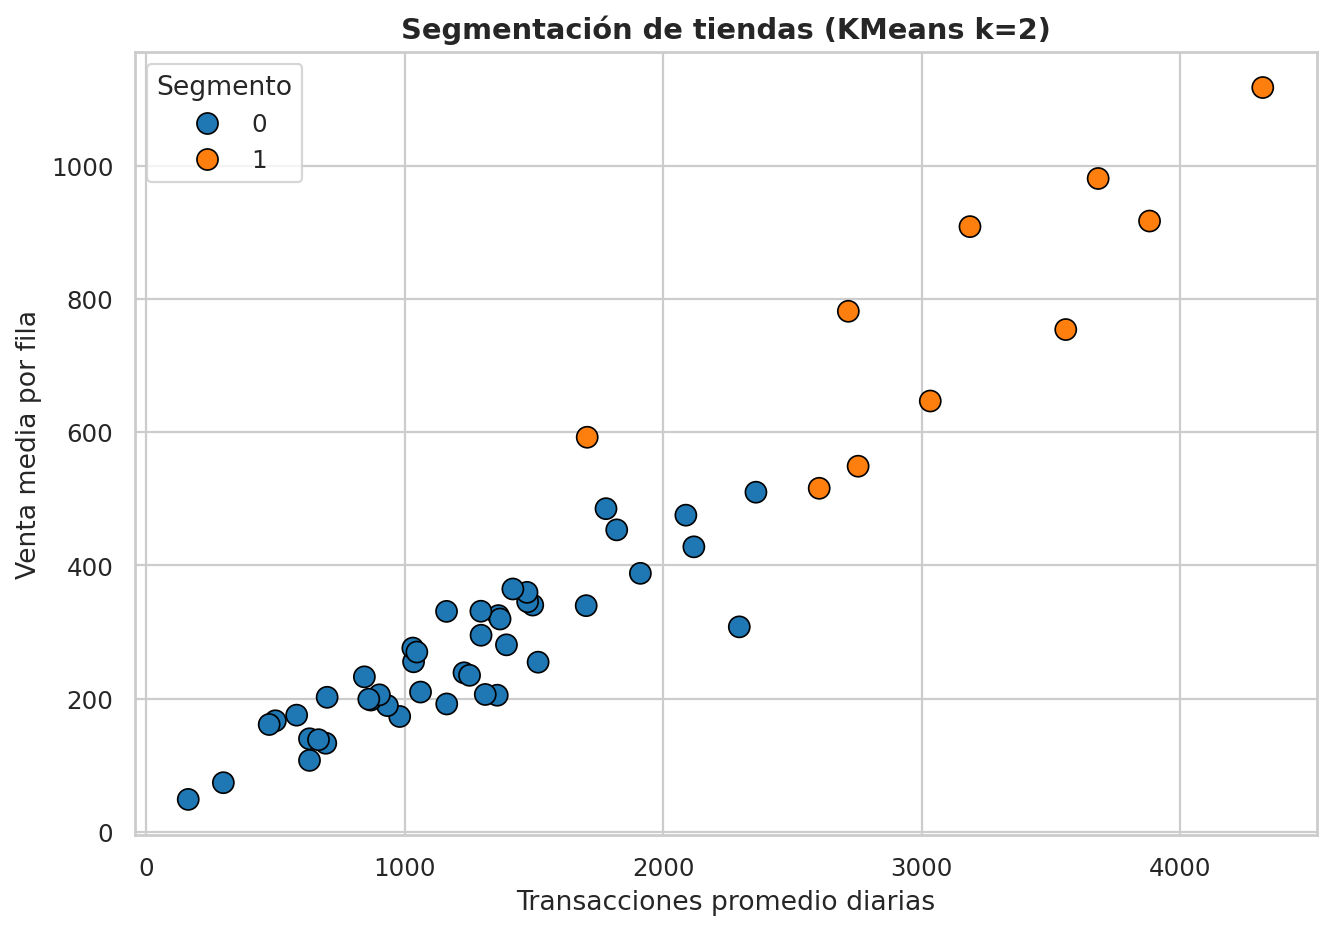

In [35]:
display(Image(filename=str(figures / '18_segmentacion_tiendas_kmeans.png'), width=700))

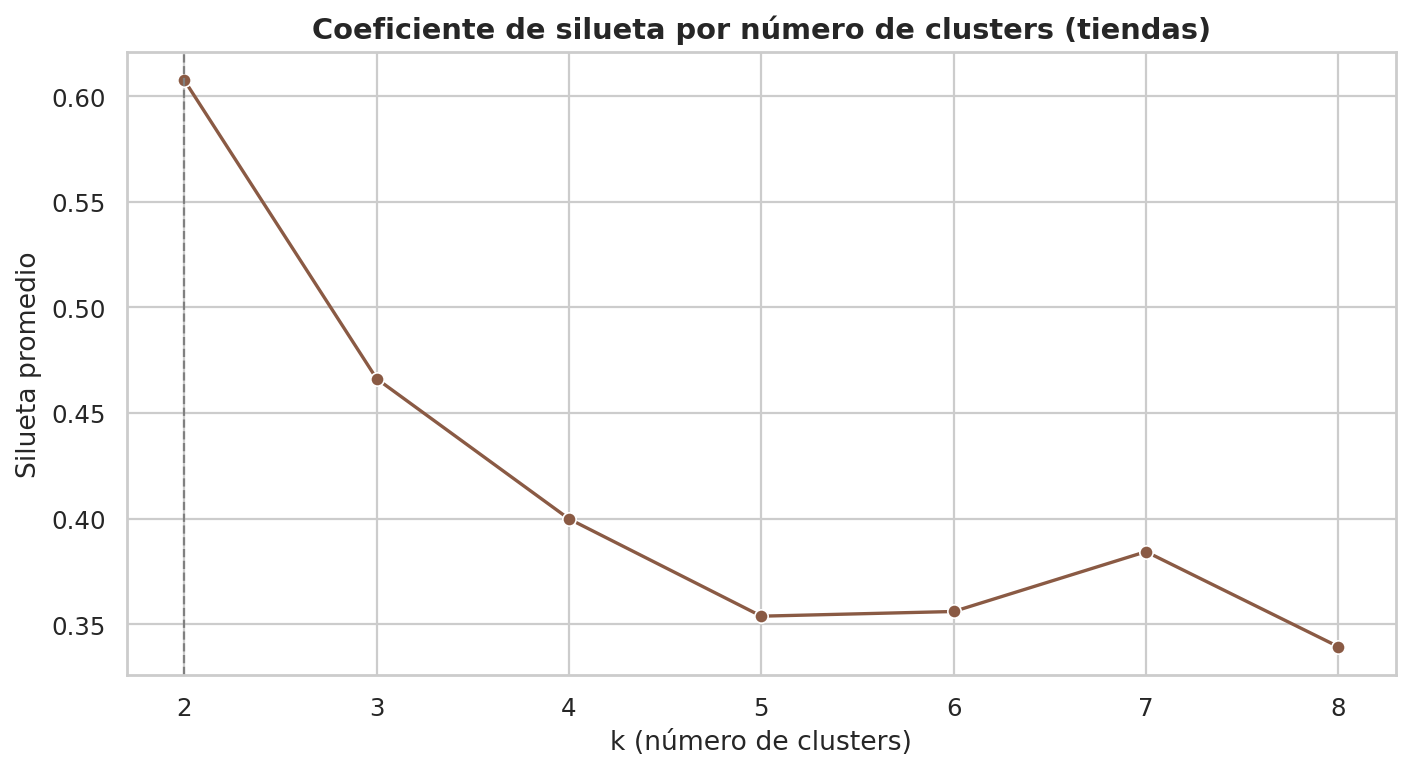

In [36]:
display(Image(filename=str(figures / '19_silueta_k_tiendas.png'), width=700))

### Interpretacion - Clustering
- **Mejor k para tiendas = 2** con silueta = **0.61** (buena separacion).
- **Segmento 0** (44 tiendas): ventas medias bajas (263), transacciones moderadas (1,195), baja demanda alta (14%).
- **Segmento 1** (10 tiendas): ventas altas (776), alto flujo (3,144), alta demanda (61%). Son las tiendas "premium".
- La curva de silueta decrece hasta k=5 y luego se estabiliza - k=2 es la particion mas clara.
- **Familias:** silueta optima de **0.71** con k=2, aun mejor separacion.

> **Conclusion:** La data es **apta para clustering**. Los segmentos son interpretables y diferenciables, validando la segmentacion como herramienta analitica.

---
## 11. Resumen de Metricas y Conclusiones Finales

### Metricas Clave del EDA

In [37]:
print("=" * 70)
print("           METRICAS CLAVE DEL ANALISIS EXPLORATORIO")
print("=" * 70)
print()
print("--- DATASET ---")
print("  Archivos procesados:          7/7 (todos presentes)")
print("  Filas en train:               3,000,888")
print("  Rango temporal:               2013-01-01 a 2017-08-15 (4.6 anios)")
print("  Tiendas:                      54")
print("  Familias de producto:         33")
print("  Columnas integradas:          30 (27 predictoras)")
print()
print("--- CALIDAD ---")
print("  Duplicados:                   0 (en todos los archivos)")
print("  Nulos en train:               0%")
print("  Nulos en oil:                 3.5% (imputados con ffill)")
print("  Ventas en cero:               31.3% (939,130 filas)")
print("  Ventas negativas:             0")
print("  Consistencia referencial:     100% (0 tiendas huerfanas)")
print()
print("--- VARIABLE OBJETIVO (sales) ---")
print("  Media:                        357.78")
print("  Mediana:                      11.00")
print("  Desviacion estandar:          1,102.00")
print("  Asimetria (cruda):            7.36")
print("  Asimetria (log1p):            0.41  --> transformacion recomendada")
print("  Curtosis (cruda):             154.56")
print("  Curtosis (log1p):             -1.15")
print("  Coef. variacion:              3.08")
print()
print("--- PREDICTORAS MAS RELEVANTES ---")
print("  1. onpromotion:               r = 0.4279  (senal fuerte)")
print("  2. transactions_filled:       r = 0.2331  (senal moderada)")
print("  3. year:                      r = 0.0811  (tendencia)")
print("  4. dcoilwtico:                r = -0.0748 (espuria)")
print("  5. is_weekend:                r = 0.0519  (patron semanal)")
print()
print("--- ESTACIONALIDAD ---")
print("  Mes pico (diciembre):         Indice = 1.349  (+35%)")
print("  Mes valle (febrero):          Indice = 0.862  (-14%)")
print("  Crecimiento YoY promedio:     ~23% (2014-2016)")
print()
print("--- CLASIFICACION (demanda_alta) ---")
print("  Clase positiva:               22.37% (671,267 filas)")
print("  Clase negativa:               77.63% (2,329,621 filas)")
print("  Ratio desbalance:             3.47:1")
print("  Tecnica recomendada:          SMOTE / class_weight")
print()
print("--- CLUSTERING ---")
print("  Mejor k (tiendas):            2")
print("  Silueta (tiendas):            0.6075")
print("  Mejor k (familias):           2")
print("  Silueta (familias):           0.7052")
print()
print("--- FIGURAS GENERADAS ---")
print("  Total:                        19 figuras en figures/")
print()
print("=" * 70)
print("                         VEREDICTO FINAL")
print("=" * 70)
print()
print("  REGRESION:      APTA - Objetivo numerico con 27 predictoras integradas.")
print("  CLASIFICACION:  APTA - Desbalance cuantificado, justifica SMOTE.")
print("  CLUSTERING:     APTA - Silueta positiva, segmentos interpretables.")
print()
print("  RECOMENDACIONES:")
print("    1. Transformar sales con log1p para regresion.")
print("    2. Validacion temporal estricta (sin fuga de futuro).")
print("    3. Ingenieria de rezagos y medias moviles.")
print("    4. Codificacion adecuada de categoricas de alta cardinalidad.")
print("    5. Balanceo de clases para el modulo de clasificacion.")
print("    6. Usar segmentos de tiendas como feature adicional.")
print("=" * 70)

           METRICAS CLAVE DEL ANALISIS EXPLORATORIO

--- DATASET ---
  Archivos procesados:          7/7 (todos presentes)
  Filas en train:               3,000,888
  Rango temporal:               2013-01-01 a 2017-08-15 (4.6 anios)
  Tiendas:                      54
  Familias de producto:         33
  Columnas integradas:          30 (27 predictoras)

--- CALIDAD ---
  Duplicados:                   0 (en todos los archivos)
  Nulos en train:               0%
  Nulos en oil:                 3.5% (imputados con ffill)
  Ventas en cero:               31.3% (939,130 filas)
  Ventas negativas:             0
  Consistencia referencial:     100% (0 tiendas huerfanas)

--- VARIABLE OBJETIVO (sales) ---
  Media:                        357.78
  Mediana:                      11.00
  Desviacion estandar:          1,102.00
  Asimetria (cruda):            7.36
  Asimetria (log1p):            0.41  --> transformacion recomendada
  Curtosis (cruda):             154.56
  Curtosis (log1p):            

---
## 12. Artefactos Generados

| Tipo | Ubicacion | Contenido |
|------|-----------|-----------|
| Tablas intermedias | `data/processed/*.csv` | 40+ archivos con metricas, perfiles y segmentaciones |
| Figuras | `figures/01..19_*.png` | 19 visualizaciones del analisis |
| Reporte completo | `reporte_eda.md` | Documento detallado con todas las tablas y figuras |
| Notebook reproducible | `notebooks/eda.ipynb` | Este notebook |

> **Para regenerar todo el analisis**, basta con ejecutar la primera celda de codigo (`spc.run_pipeline()`).